In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})

# running new things 
from scipy.stats import ttest_rel
import numpy as np

sns.set_style("ticks")

def convert_pvalue(test, pvalue):
    if np.isnan(test):
        return 0
    if pvalue <= 0.01:
        return "{:.3f}***".format(test)
    elif pvalue <= 0.05:
        return "{:.3f}**".format(test)
    elif pvalue <= 0.1:
        return "{:.3f}*".format(test)
    return "{:.3f}".format(test)


# Commit
def update_zone(zone_number):
    dic_zone = {1: 'North Central', 2: 'South South', 3: 'South East', 4: 'South West'}
    return dic_zone[zone_number]
    
# Function to remove left padding from a specific column
def set_pad_for_column(table, col, pad=0.05):
    for key, cell in table._cells.items():
        if key[1] == col:
            cell._text.set_ha('left') # Align text to the left
            cell.PAD = pad
path_raw =  '../Data/drive-download-20231006T131216Z-001/Files/Data Cleaning - Individual Files/Original Files - Not Cleaned/CMS (entire database)/Files/'

# CMS Responses

In [2]:
df_CMS = pd.read_stata('../Data/drive-download-20231006T131216Z-001/Files/CMS Responses.dta')
#df_CMS['A06_Relatn_hhd'].unique()# ()
for i in df_CMS.keys():
    print(i)

ZoneID
StateID
LgaID
LocalityID
EnumerationID
HouseID
Individual_family_code
A01_Name_hhd_member
A02_Sex
A03_Age
A04_Marital_status
A05_Edu
A06_Relatn_hhd
A07_1_Main_occupatn
A07_1b_S_OCCUPATION
A07_2_Secondary_occupation
A08_fam_lab_contributn
Men_In_House
Women_In_House
Kids
Male_Managed
Female_Managed
Joint_Managed
Male_ICV_Managed
Female_ICV_Managed
Joint_ICV_Managed
Male_NonICV_Managed
Female_NonICV_Managed
Joint_NonICV_Managed
Household_ICV
Household_NonICV
Household_Plots
ICV_Plot_Size
NonICV_Plot_Size
Male_ICV_PlotSize
Female_ICV_PlotSize
Joint_ICV_PlotSize
Male_NonICV_PlotSize
Female_NonICV_PlotSize
Joint_NonICV_PlotSize
Household_ICV_Total_Size
Household_NonICV_Total_Size
House_Cassava_Plot_TotalSize
Avg_Plot_Size
planted
J01_hhd_apply_fert
J02_per_hh_inc_cassav
J03_women_incm
J04_hhd_food_incm
J05_sales_perc
J05_consumption_perc
J05_Others_perc
J05_all_CASSAPERCENTCHECK
Coop_Group_Member
Men_Only_Coop
Women_Only_Coop
Joint_Coop
Male_Credit_Only
Female_Credit_Only
Joint_Credi

# DNA Fingerprinting

In [3]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_DNA = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_CMS['HouseID'].value_counts().keys()
df_DNA = df_DNA[df_DNA['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_DNA.columns = ['HouseID', 'ZoneID', 'Total ICV - DNA', 'Y_N ICV - DNA']
df_DNA['ZoneID'] = (df_DNA['ZoneID']/10).astype(int)#.tail()
df_DNA.shape# ()

(2477, 4)

# Intrahousehold and DNA fingerprinting

In [4]:
df_M_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Husband Responses.dta')
df_M_raw = df_M_raw[(df_M_raw['A02_Sex'] == 'Male') & 
                    (df_M_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_M_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)


df_F_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/Files/Wife Responses.dta')
df_F_raw = df_F_raw[(df_F_raw['A02_Sex'] == 'Female') &
                    (df_F_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_F_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)


df_allMF = pd.concat([df_M_raw, df_F_raw]).reset_index(drop=True)
both_responses = (df_allMF['HouseID'].value_counts()).to_frame()
both_responses = both_responses[both_responses['count']== 2]
df_allMF = df_allMF[df_allMF['HouseID'].isin(both_responses.index)]

df_M = df_allMF[df_allMF['A02_Sex'] == 'Male']
df_M = df_M.reset_index(drop=True)

df_F = df_allMF[df_allMF['A02_Sex'] == 'Female']
df_F = df_F.reset_index(drop=True)

# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_H_dna = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_M['HouseID'].value_counts().keys()
df_H_dna = df_H_dna[df_H_dna['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_H_dna.columns = ['HouseID', 'ZoneID', 'Household_ICV', 'planted']
df_H_dna['ZoneID'] = (df_H_dna['ZoneID']/10).astype(int)#.tail()
df_H_dna.head()

df_H_dna.shape

(729, 4)

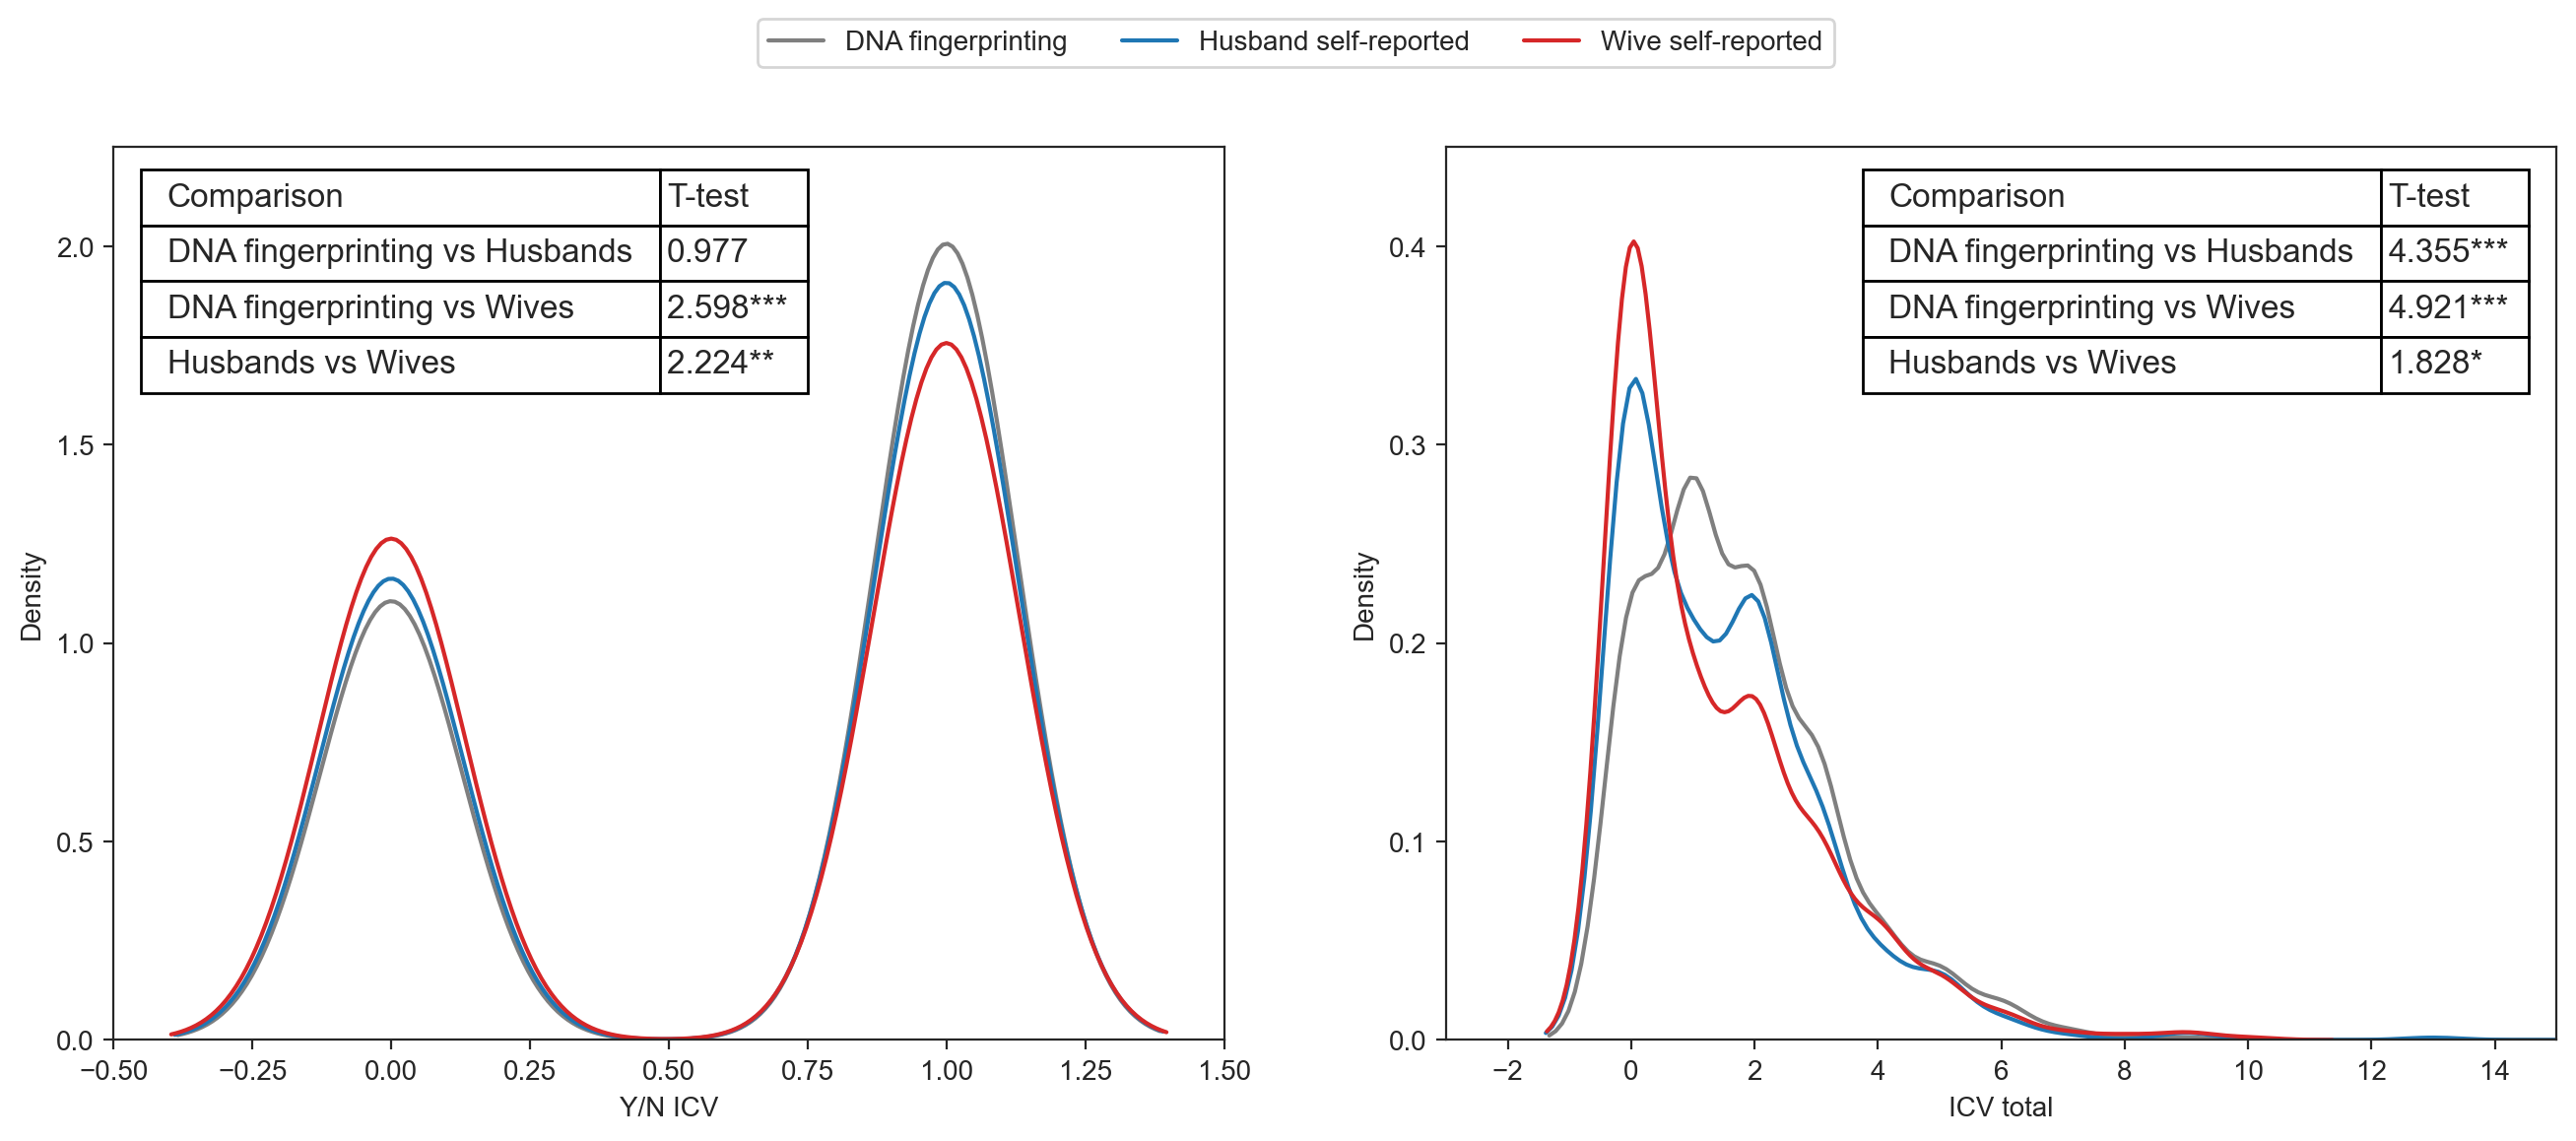

In [5]:
fig1, ax1 = plt.subplots(1, 2, figsize=(16,6), dpi=200)

for index, var in enumerate(['planted', 'Household_ICV']):
    #fig1, ax1 = plt.subplots(dpi=100, figsize=(8, 6))

    ttest_HM = ttest_rel(df_H_dna[f'{var}'], df_M[f'{var}'], nan_policy='omit')
    ttest_HF = ttest_rel(df_H_dna[f'{var}'], df_F[f'{var}'], nan_policy='omit')
    ttest_MF = ttest_rel(df_M[f'{var}'], df_F[f'{var}'], nan_policy='omit')

    data = []
    data.append(['DNA fingerprinting vs Husbands', convert_pvalue(ttest_HM[0], ttest_HM[1])])
    data.append(['DNA fingerprinting vs Wives', convert_pvalue(ttest_HF[0], ttest_HF[1])])
    data.append(['Husbands vs Wives', convert_pvalue(ttest_MF[0], ttest_MF[1])])

    df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])

    sns.kdeplot(df_H_dna[var], ax = ax1[index],  color="C7", label ="DNA fingerprinting")
    sns.kdeplot(df_M[var], ax = ax1[index], color="C0", label ="Husband self-reported")
    sns.kdeplot(df_F[var], ax = ax1[index], color="C3", label ="Wive self-reported")
    ax1[index].set_xlabel(var)

    bbox_place = (0.025, 0.725, 0.6, 0.25) if index == 0 else (0.375, 0.725, 0.6, 0.25)
    the_table = ax1[index].table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
              colLoc='right', colWidths=[0.7, 0.2], bbox = bbox_place,  zorder=10)
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(12)
            
    # Remove left padding from all columns
    for i in range(len(df_ttest.values)):
        set_pad_for_column(the_table, i)
    
    # ax1.set_title(labels[index])
    ax1[0].set_ylim(0, 2.25)
    ax1[1].set_ylim(0, 0.45)
    ax1[0].set_xlim(-0.5, 1.5)
    ax1[1].set_xlim(-3, 15)
    
    ax1[0].set_yticks([0, 0.5, 1, 1.5, 2])
    ax1[1].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
    
    ax1[index].set_ylabel('Density')
    ax1[index].set_xlabel('Y/N ICV' if var == 'planted' else 'ICV total')

h, l = ax1[0].get_legend_handles_labels()

fig1.legend(h, l, loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1))
fig1.savefig(f"../Manuscript/Figures/Figure_2.pdf", dpi=600, bbox_inches='tight' )

# By Zone

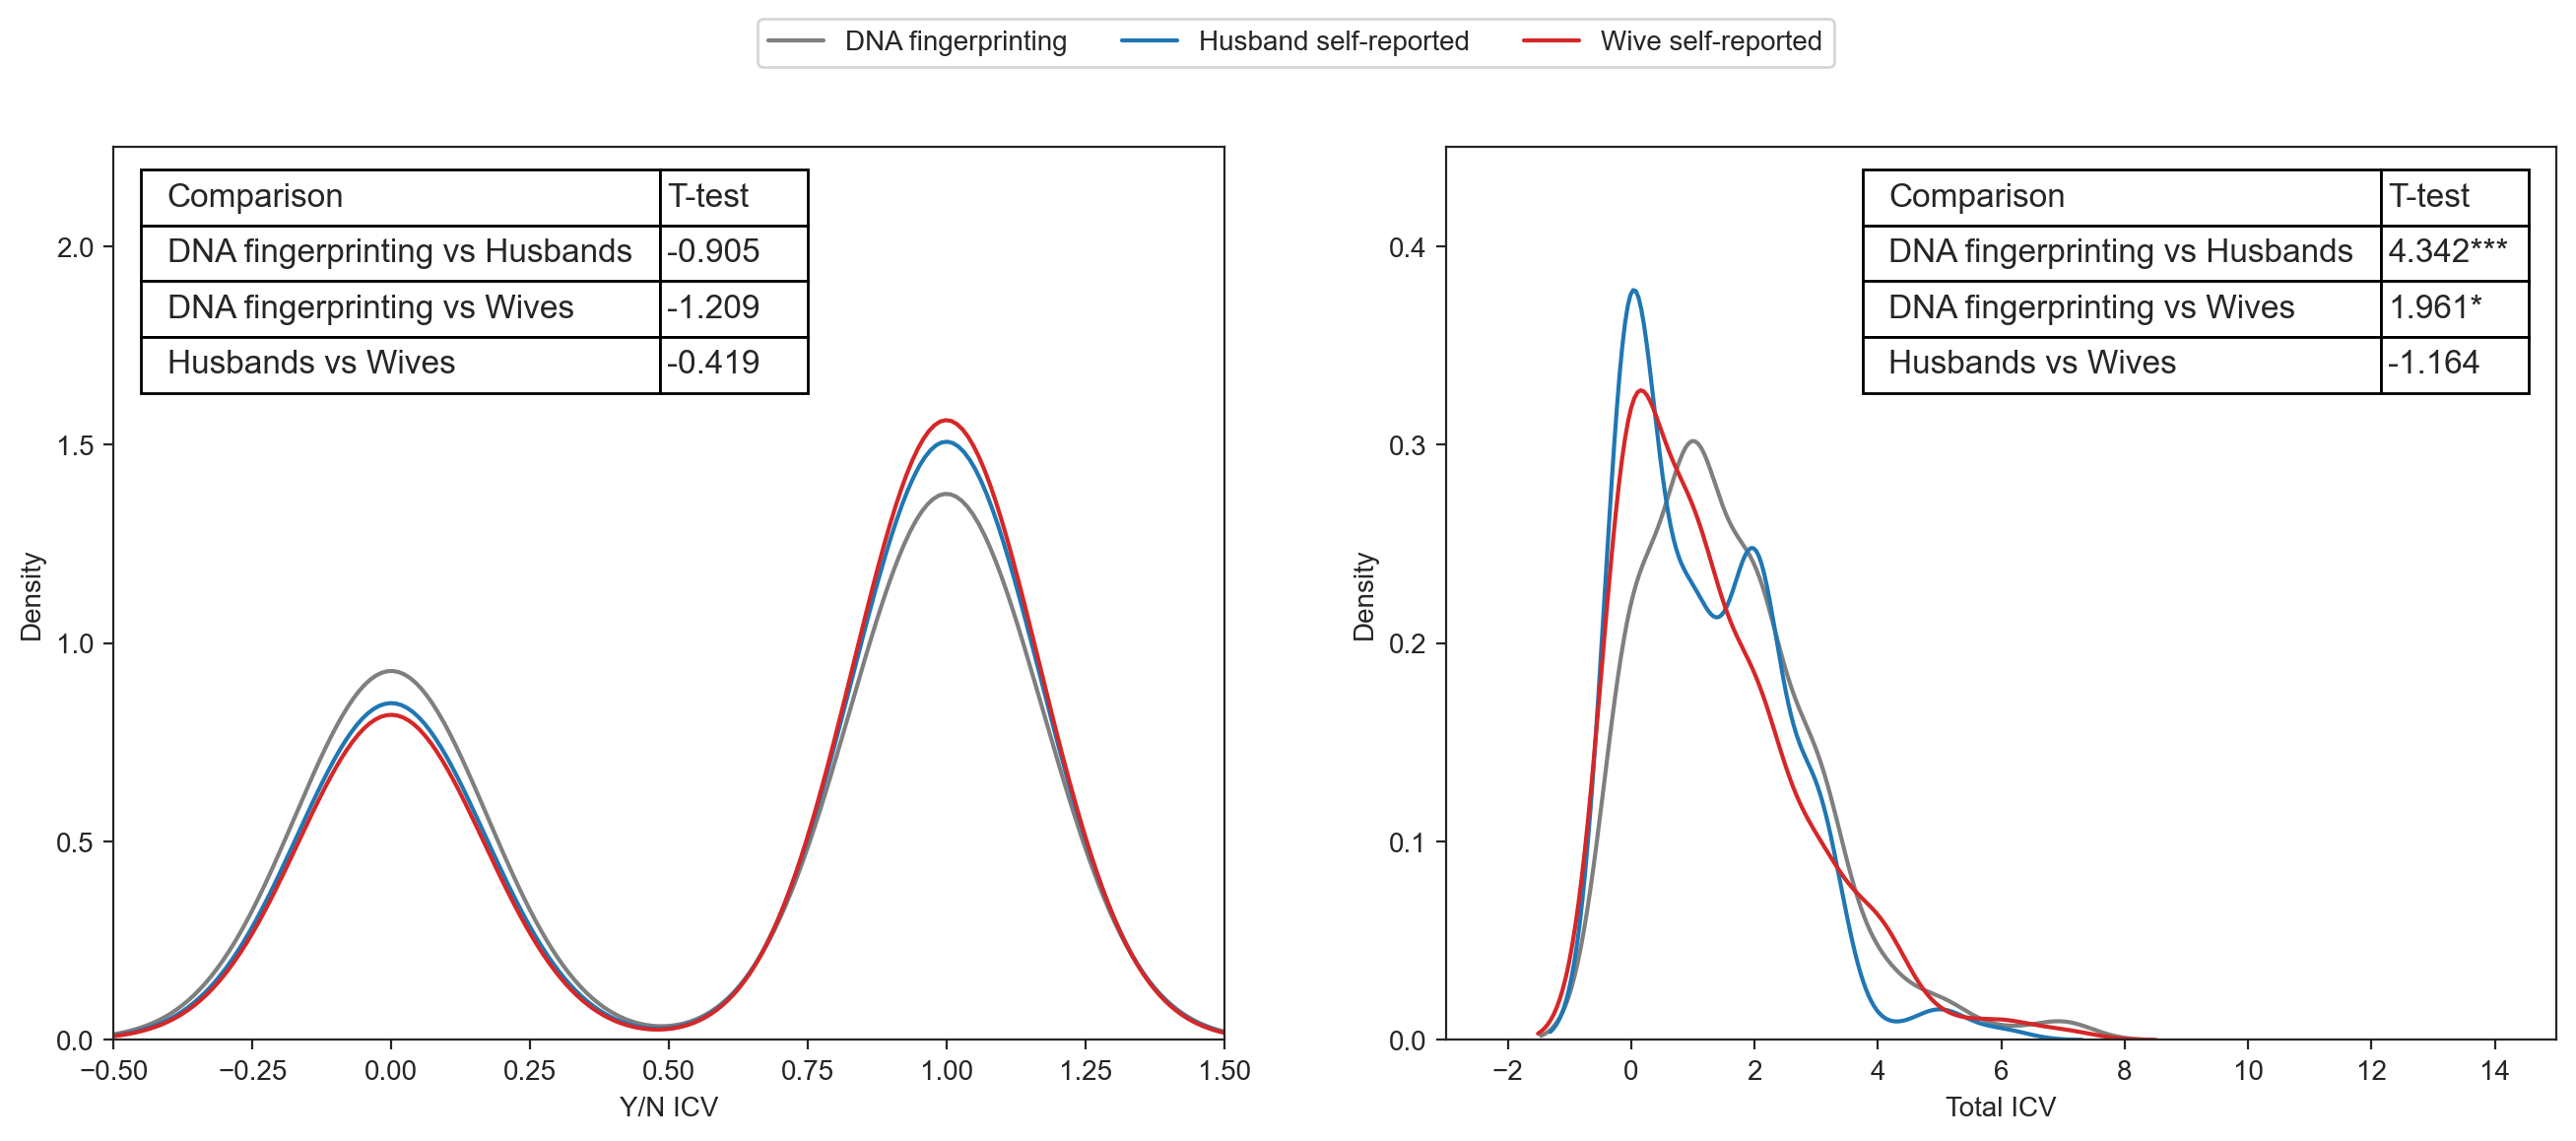

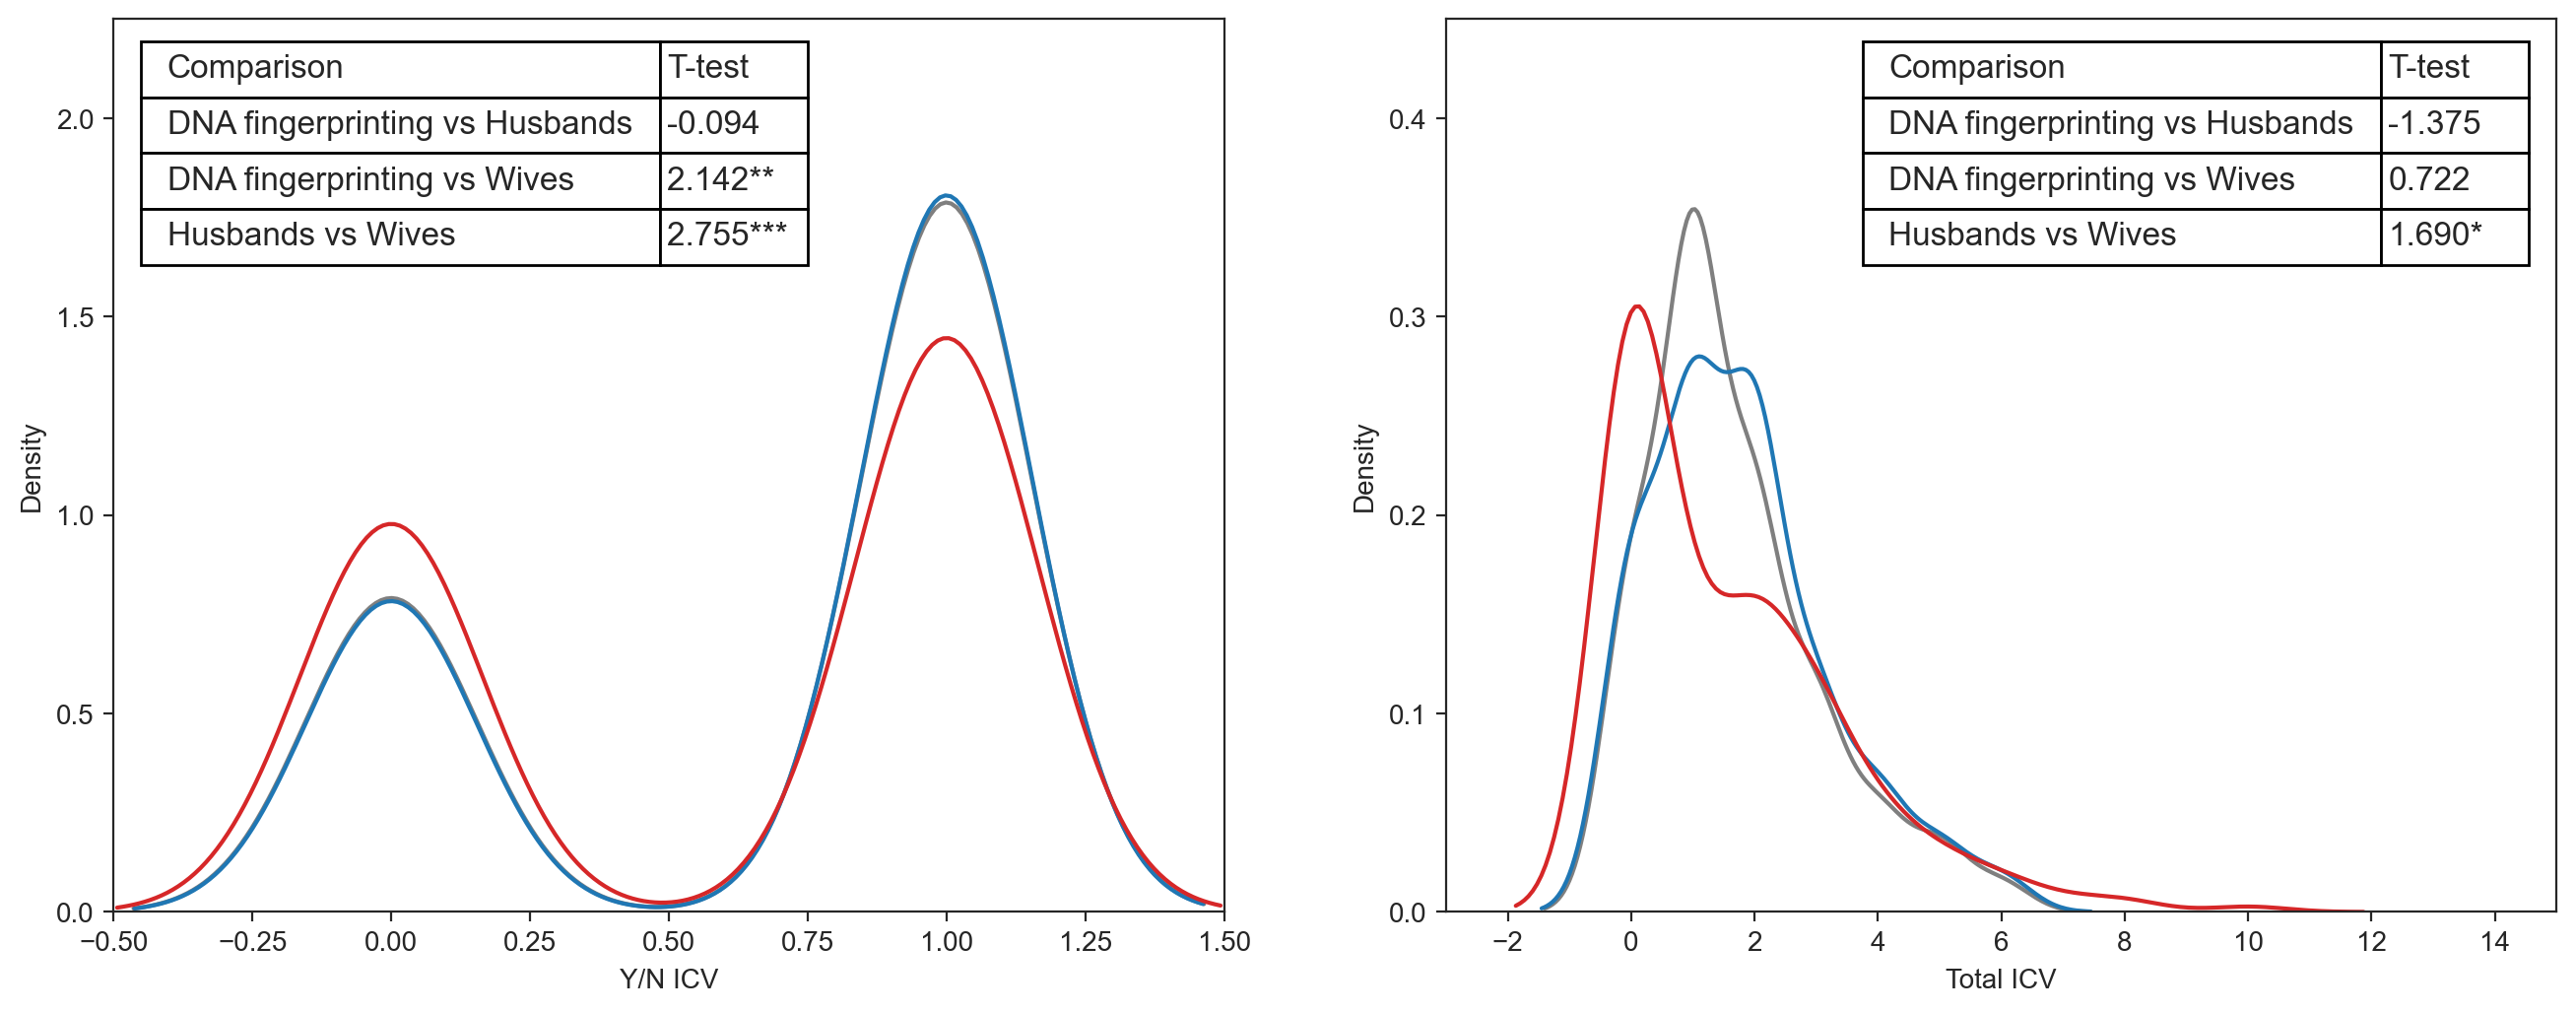

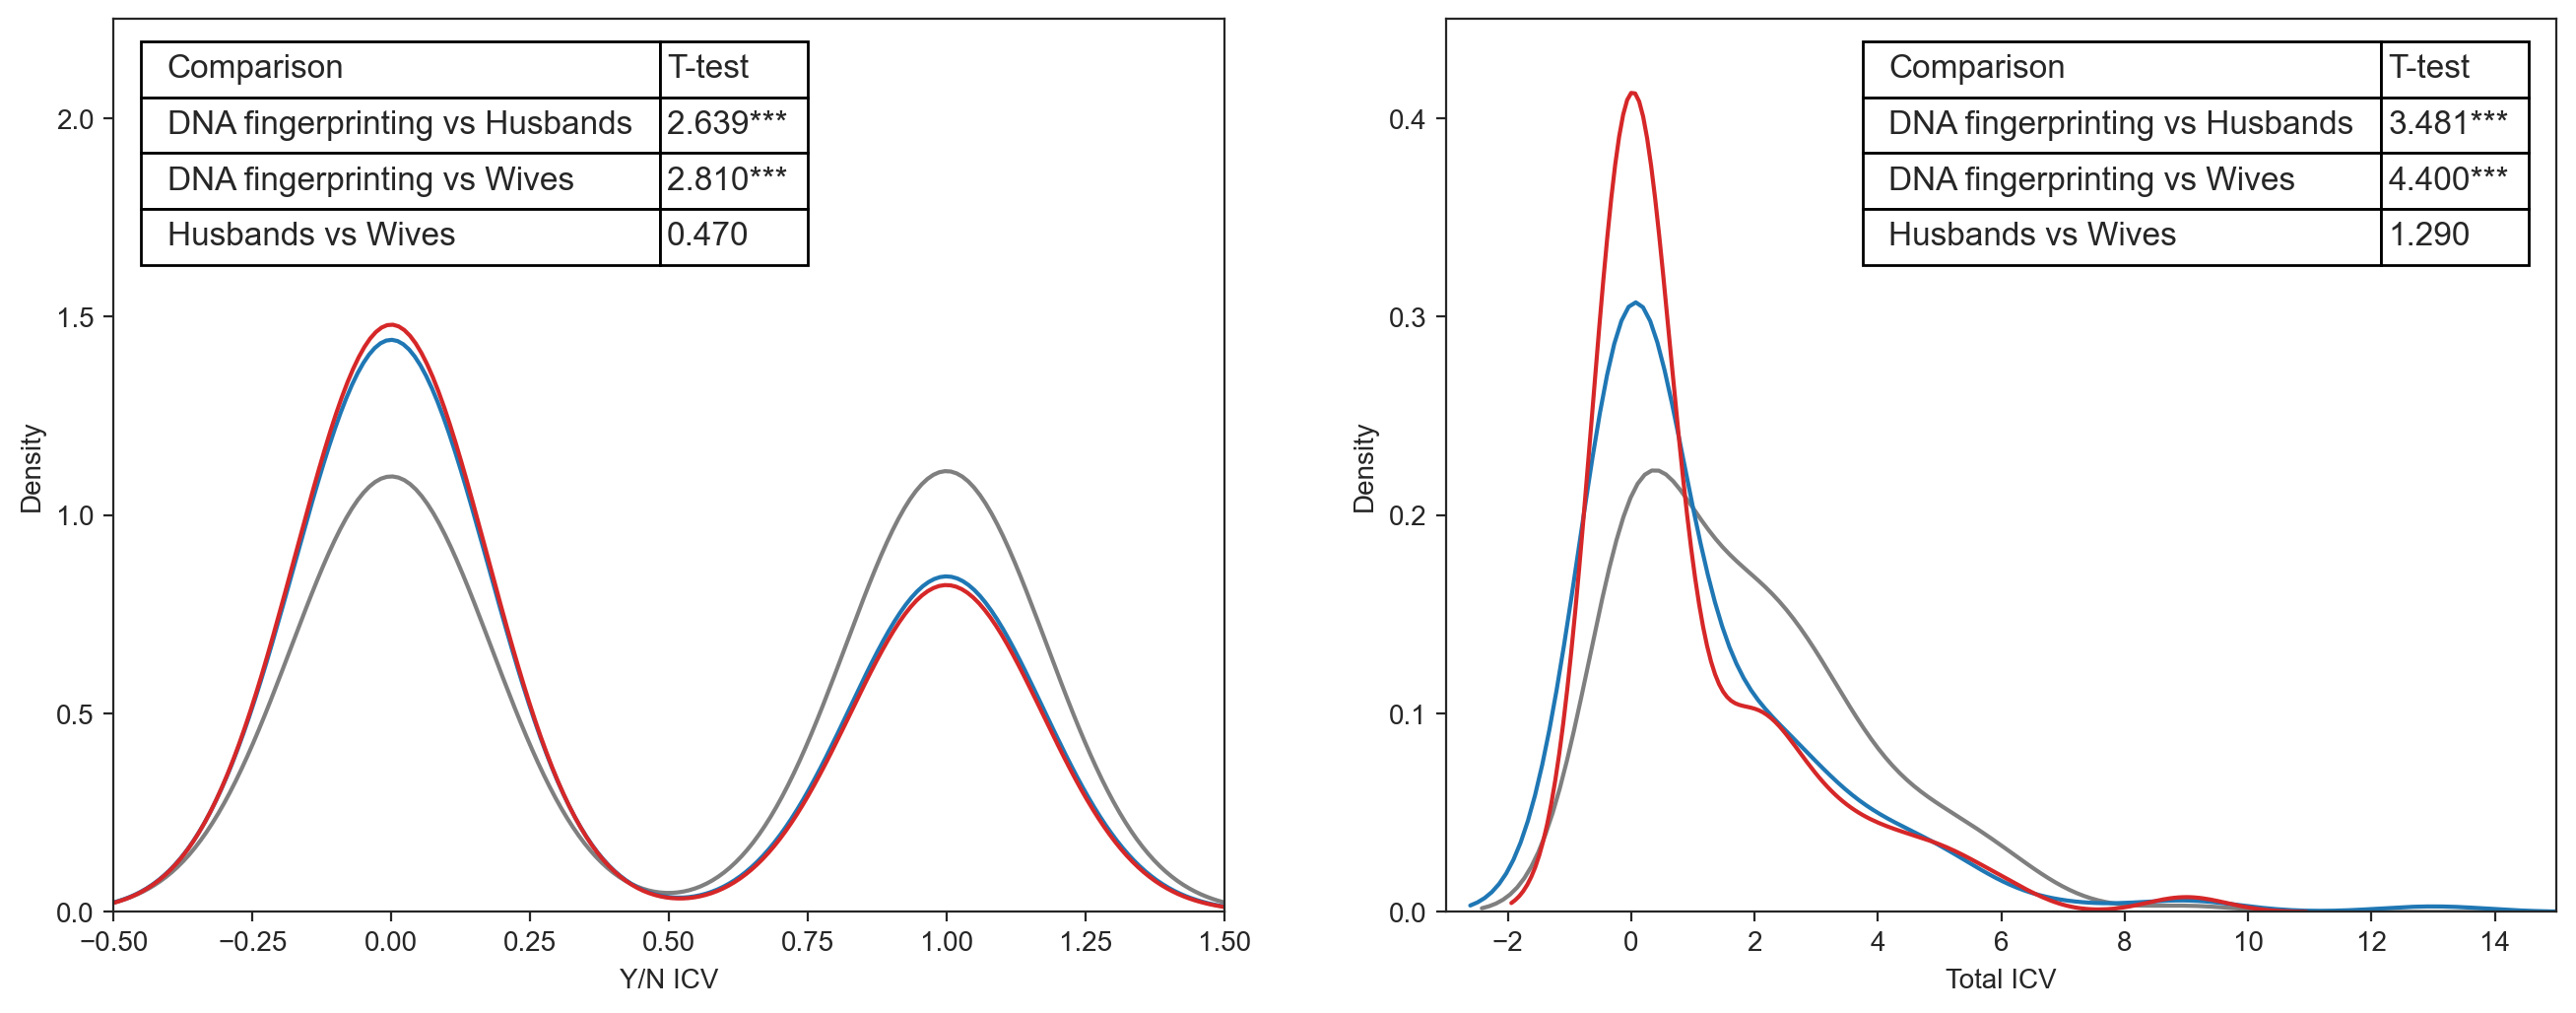

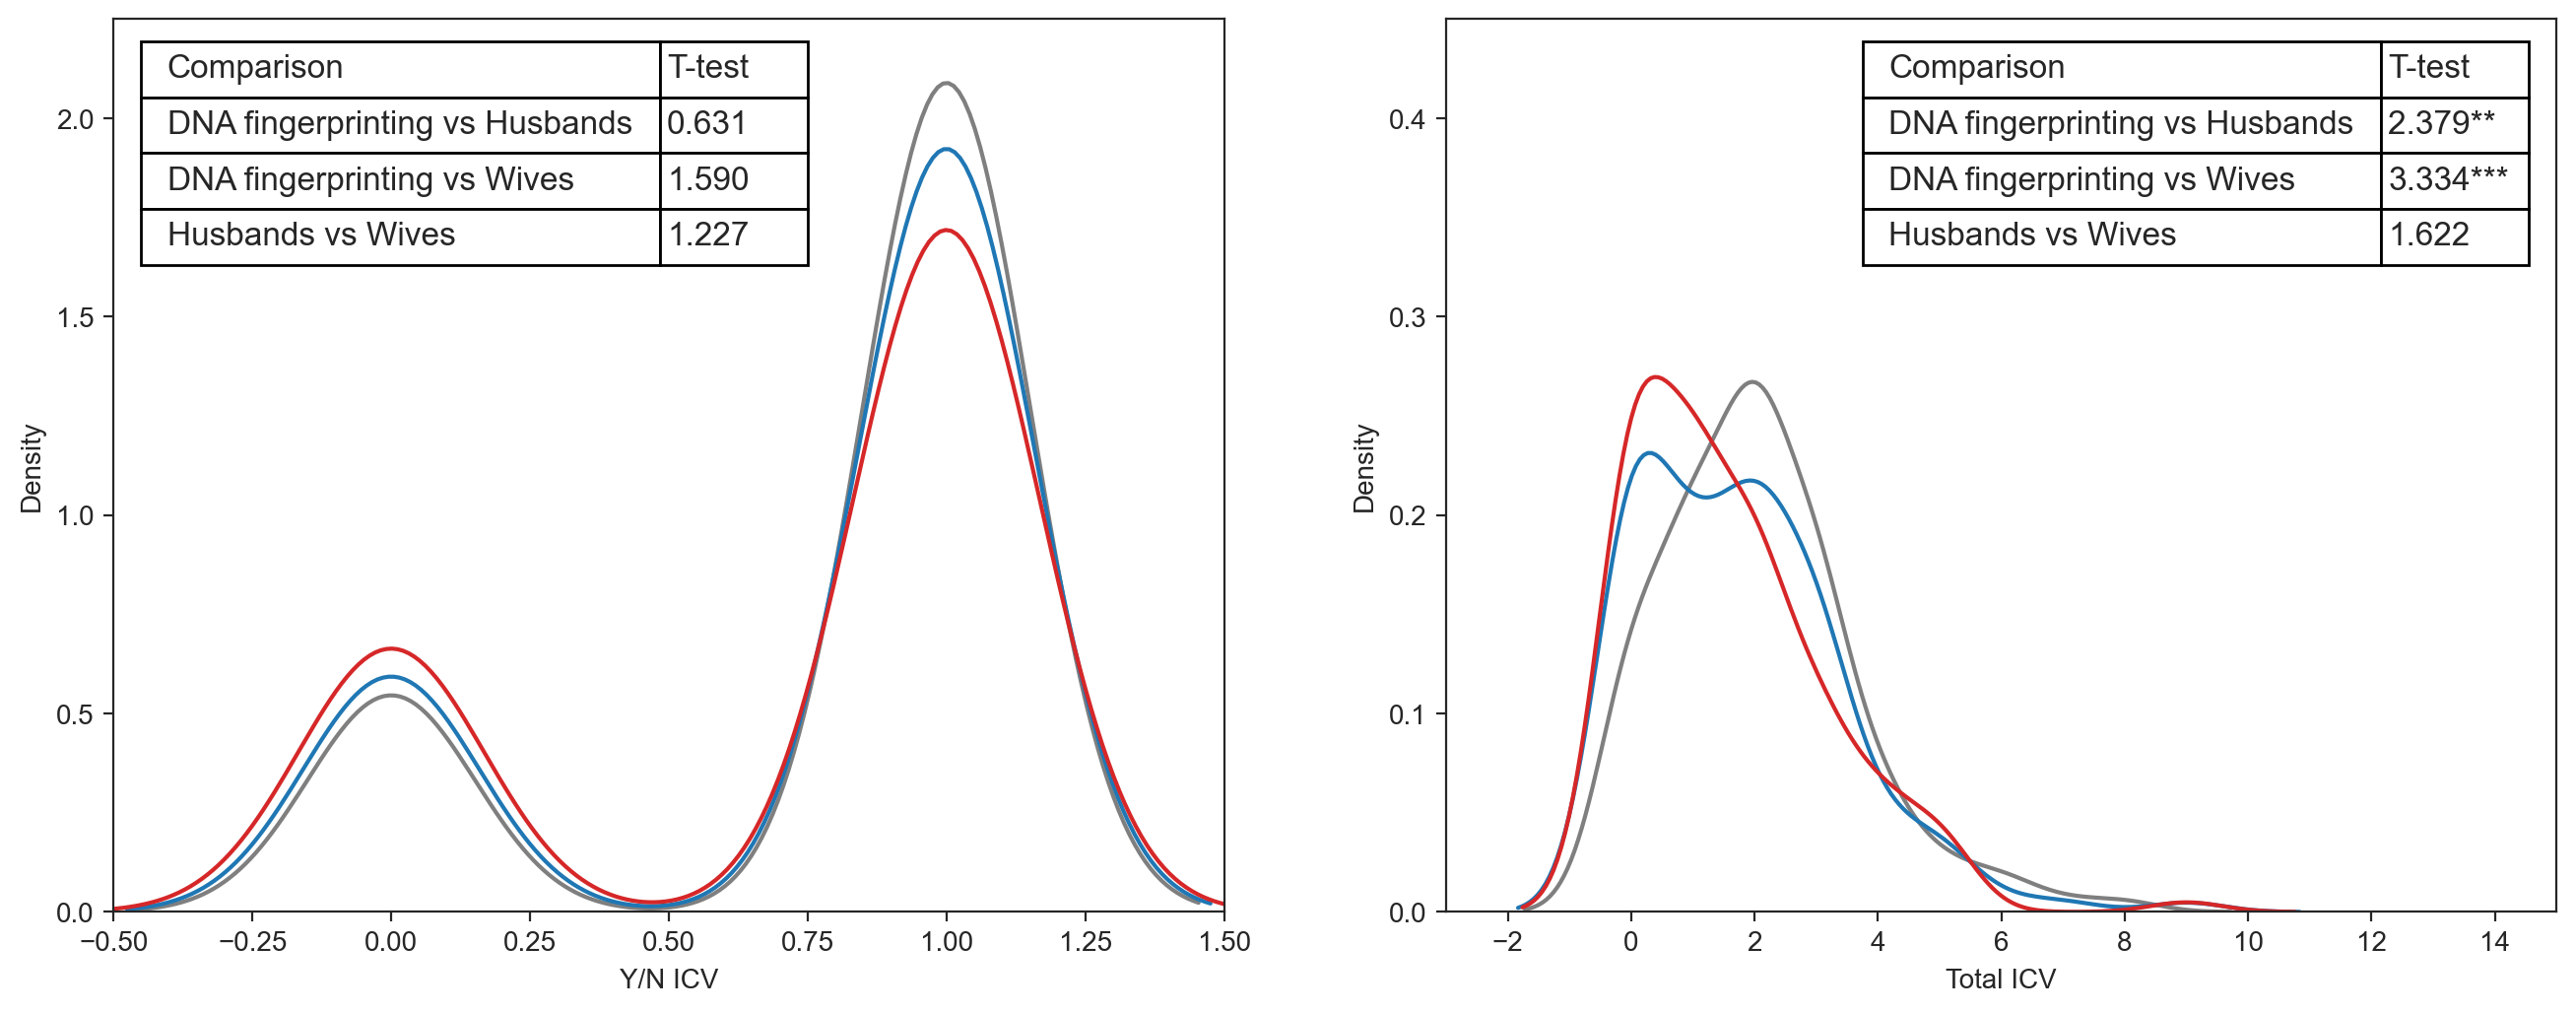

In [6]:
for zone in df_F['ZoneID'].unique():        
    fig1, ax1 = plt.subplots(1, 2, figsize=(16,6), dpi=200)
    for index, var in enumerate(['planted', 'Household_ICV']):
        df_F_tmp = df_F[df_F['ZoneID'] == zone]
        df_M_tmp = df_M[df_M['ZoneID'] == zone]
        df_H_dna_tmp = df_H_dna[df_H_dna['ZoneID'] == zone]
        
        ttest_HM = ttest_rel(df_H_dna_tmp[f'{var}'], df_M_tmp[f'{var}'], nan_policy='omit')
        ttest_HF = ttest_rel(df_H_dna_tmp[f'{var}'], df_F_tmp[f'{var}'], nan_policy='omit')
        ttest_MF = ttest_rel(df_M_tmp[f'{var}'], df_F_tmp[f'{var}'], nan_policy='omit')
    
        data = []
        data.append(['DNA fingerprinting vs Husbands', convert_pvalue(ttest_HM[0], ttest_HM[1])])
        data.append(['DNA fingerprinting vs Wives', convert_pvalue(ttest_HF[0], ttest_HF[1])])
        data.append(['Husbands vs Wives', convert_pvalue(ttest_MF[0], ttest_MF[1])])
    
        df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])
    
        sns.kdeplot(df_H_dna_tmp[var], ax = ax1[index], fill=False, color="C7", label ="DNA fingerprinting")
        sns.kdeplot(df_M_tmp[var], ax = ax1[index], fill=False, color="C0", label ="Husband self-reported")
        sns.kdeplot(df_F_tmp[var], ax = ax1[index], fill=False, color="C3", label ="Wive self-reported")
        ax1[index].set_xlabel(var)
        
        bbox_place = (0.025, 0.725, 0.6, 0.25) if index == 0 else (0.375, 0.725, 0.6, 0.25)
        the_table = ax1[index].table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
                  colLoc='right', colWidths=[0.7, 0.2], bbox = bbox_place,  zorder=10)
        the_table.auto_set_font_size(False)
        the_table.set_fontsize(12)
                
        # Remove left padding from all columns
        for i in range(len(df_ttest.values)):
            set_pad_for_column(the_table, i)
    
        # ax1[index].set_title(labels[index])

    
        ax1[index].set_ylabel('Density')
        ax1[index].set_xlabel('Y/N ICV' if var == 'planted' else 'Total ICV')

    ax1[0].set_ylim(0, 2.25)
    ax1[1].set_ylim(0, 0.45)
    ax1[0].set_xlim(-0.5, 1.5)
    ax1[1].set_xlim(-3, 15)
    
    ax1[0].set_yticks([0, 0.5, 1, 1.5, 2])
    ax1[1].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
    # if zone == 3:
    #     ax1[0].set_ylim(0, 2.2)
    # if zone == 4:
    #     ax1[1].set_ylim(0, 0.35)
    h, l = ax1[0].get_legend_handles_labels()

    if zone == 1:
        fig1.legend(h, l, loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1))
    fig1.savefig(f"../Manuscript/Figures/Figure_3_{update_zone(zone)}.pdf", dpi=600, bbox_inches='tight' )

# Gender and DNA fingerprinting HHhead
**Merge:** CMS Responses and  DNA fingerprinting

In [7]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_DNA = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_CMS['HouseID'].value_counts().keys()
df_DNA = df_DNA[df_DNA['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_DNA.columns = ['HouseID', 'ZoneID', 'Total ICV - DNA', 'Y_N ICV - DNA']
df_DNA['ZoneID'] = (df_DNA['ZoneID']/10).astype(int)#.tail()
df_DNA.shape# ()

df_CMS_HH  = df_CMS#[df_CMS['A06_Relatn_hhd'] == 'Household head']
df_CMS_HH  = df_CMS_HH.rename(columns={'Household_ICV': 'Total ICV - Survey', 'planted': 'Y_N ICV - Survey',})
df_CMS_HH_DNA = pd.merge(df_DNA, df_CMS_HH[['HouseID', 'A02_Sex', 'Total ICV - Survey', 'Y_N ICV - Survey']], on='HouseID')
print('CMS + DNA dimensions', df_CMS_HH_DNA.shape)
print('Percentaje', df_CMS_HH_DNA['A02_Sex'].value_counts(normalize=True))
df_CMS_HH_DNA.head()

CMS + DNA dimensions (2477, 7)
Percentaje A02_Sex
Male      0.779798
Female    0.220202
Name: proportion, dtype: float64


,HouseID,ZoneID,Total ICV - DNA,Y_N ICV - DNA,A02_Sex,Total ICV - Survey,Y_N ICV - Survey
0,112111,1,1,1,Male,1.0,0.0
1,112112,1,1,1,Male,0.0,0.0
2,112113,1,3,1,Male,3.0,1.0
3,112114,1,0,0,Female,0.0,0.0
4,112115,1,0,0,Male,0.0,0.0


In [8]:

df_M = df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Male']#[['Total ICV - Survey', 'Total ICV - DNA', 'Y/N ICV - DNA']]
df_F = df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Female']#[['Total ICV - Survey', 'Total ICV - DNA', ]]
df_DNA.keys()

Index(['HouseID', 'ZoneID', 'Total ICV - DNA', 'Y_N ICV - DNA'], dtype='object')

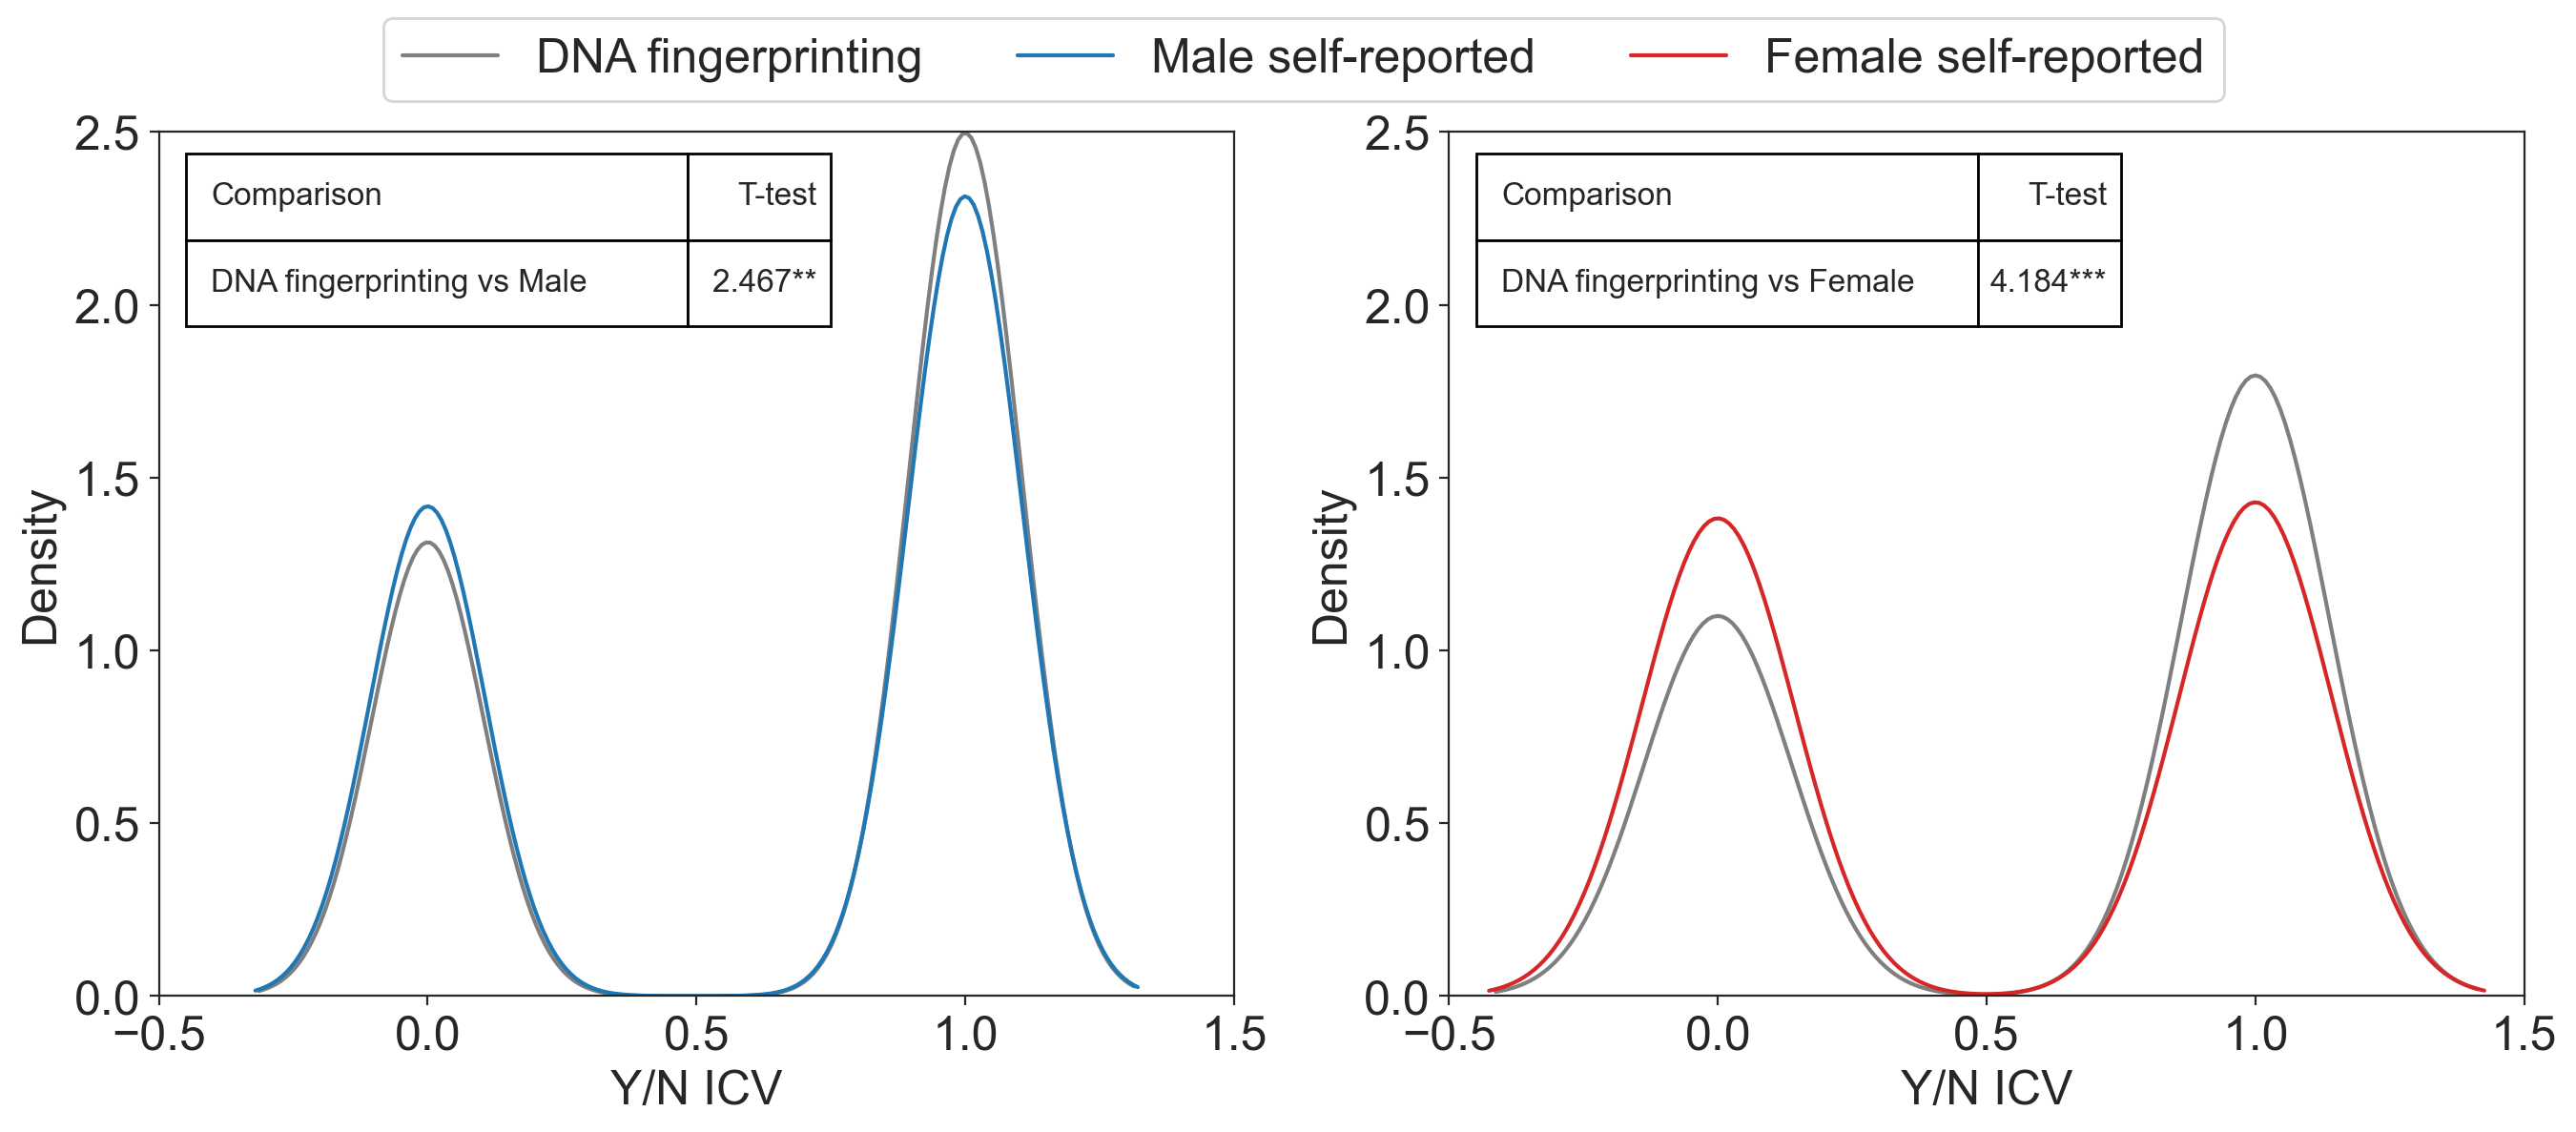

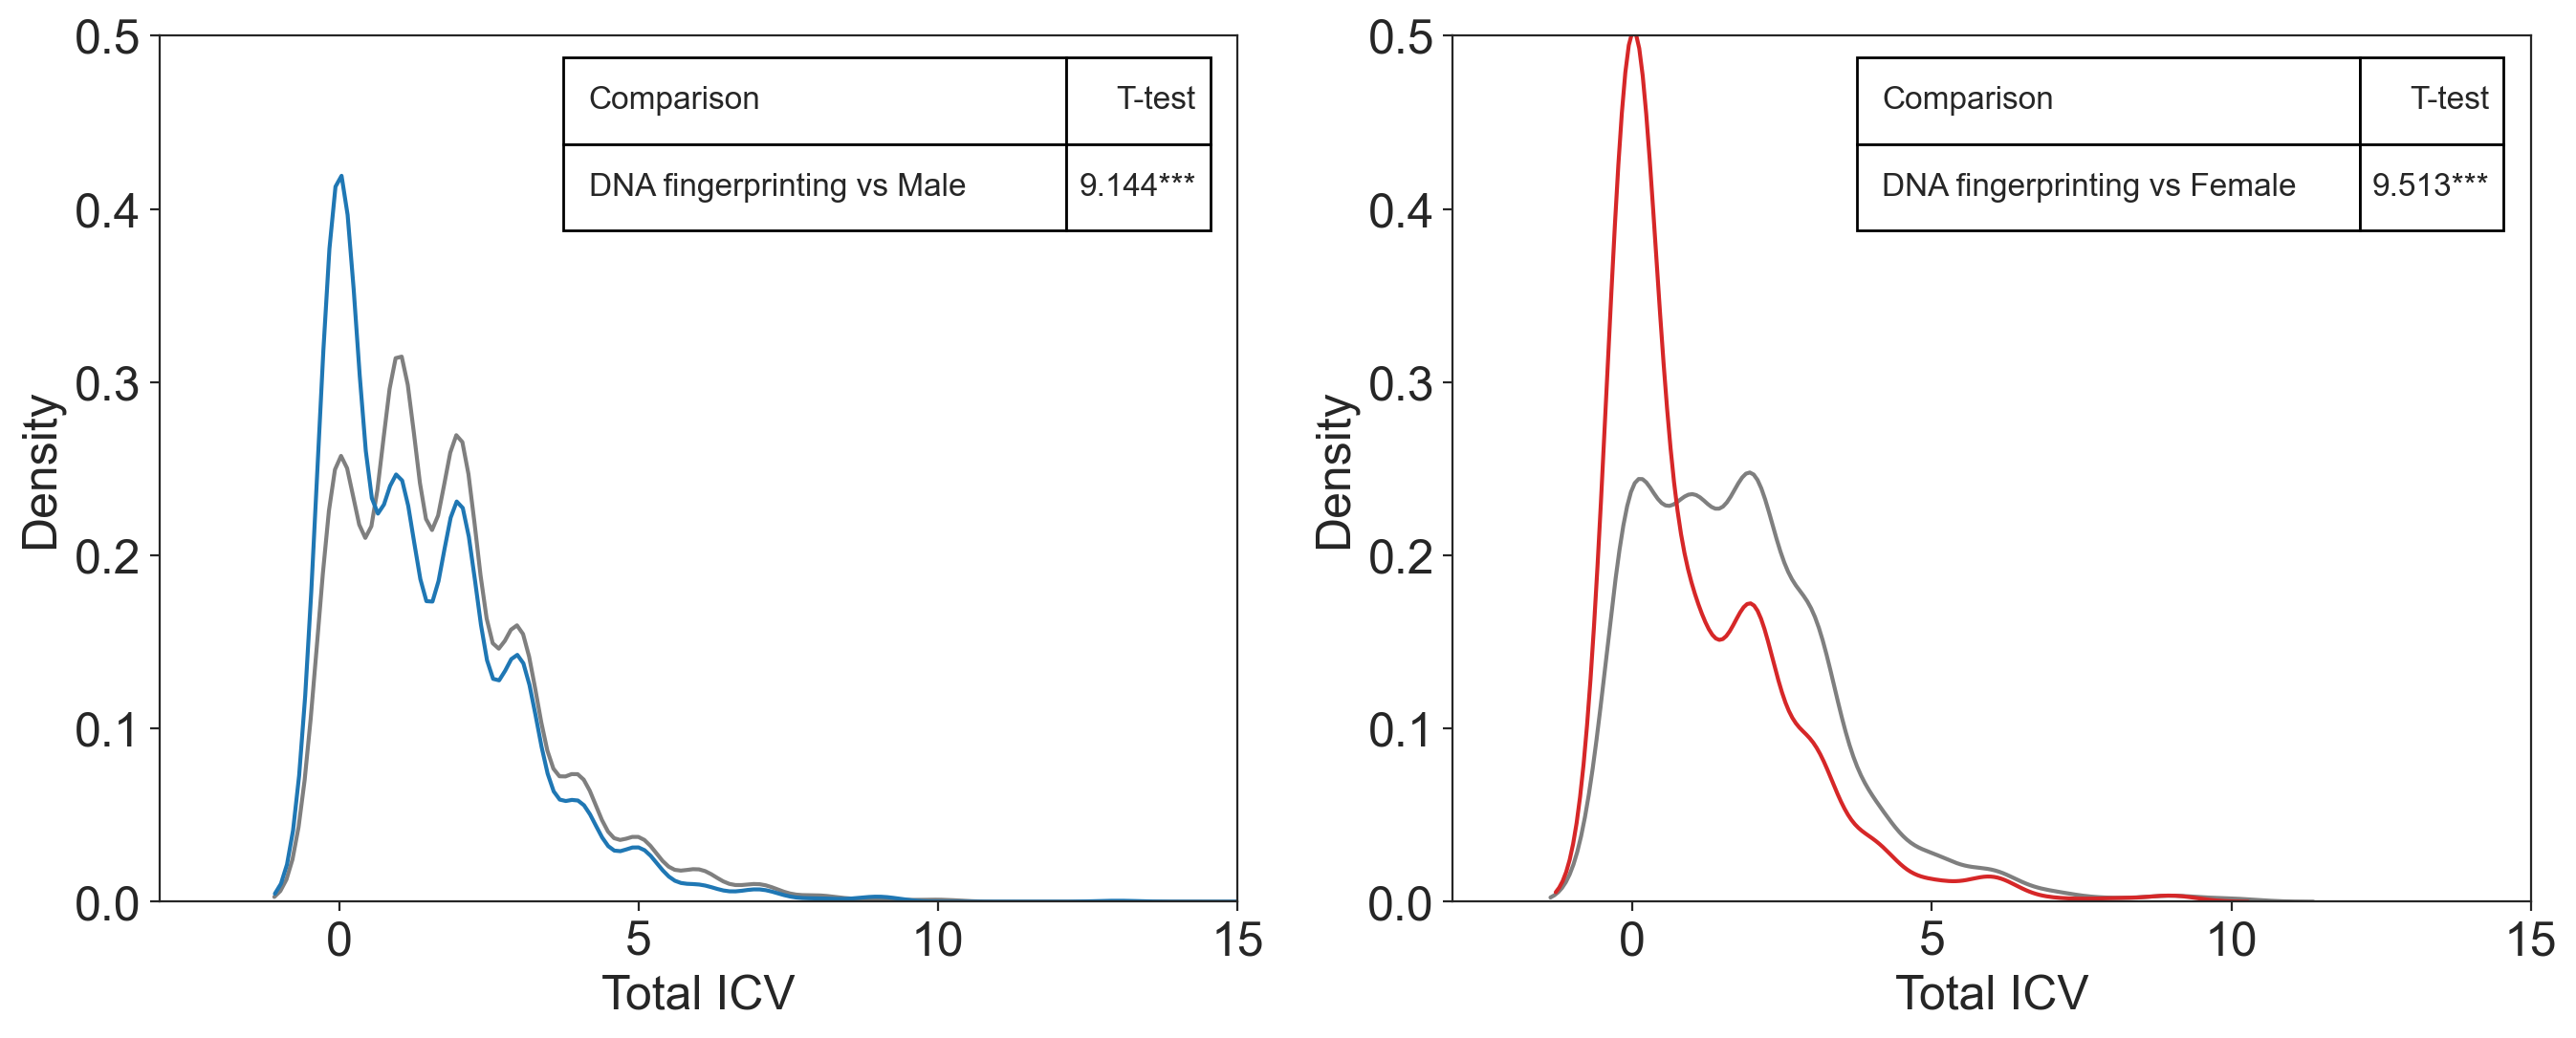

In [9]:
plt.rcParams.update({'font.size': 18})


df_M = df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Male']#[['Total ICV - Survey', 'Total ICV - DNA', 'Y/N ICV - DNA']]
df_F = df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Female']#[['Total ICV - Survey', 'Total ICV - DNA', ]]

for index, var in enumerate(['Y_N ICV', 'Total ICV']):
    fig1, ax1 = plt.subplots(1, 2, figsize=(16,6), dpi=200)

    ttest_HM = ttest_rel(df_M[f'{var} - DNA'], df_M[f'{var} - Survey'], nan_policy='omit')
    ttest_HF = ttest_rel(df_F[f'{var} - DNA'], df_F[f'{var} - Survey'], nan_policy='omit')
    
    sns.kdeplot(ax = ax1[0], data=df_M[f'{var} - DNA'], color="C7", label ="DNA fingerprinting")
    sns.kdeplot(ax = ax1[0], data=df_M[f'{var} - Survey'], color="C0", label ="Male self-reported")
    
    sns.kdeplot(ax = ax1[1], data=df_F[f'{var} - DNA'], color="C7", label ="DNA fingerprinting")
    sns.kdeplot(ax = ax1[1], data=df_F[f'{var} - Survey'], color="C3", label ="Female self-reported",)

    # ax1[0].set_title('Male')
    bbox_place = (0.025, 0.775, 0.6, 0.2) if index == 0 else (0.375, 0.775, 0.6, 0.2)


    data = []
    data.append(['DNA fingerprinting vs Male', convert_pvalue(ttest_HM[0], ttest_HM[1])])
    df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])
    the_table = ax1[0].table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
              colLoc='right', colWidths=[0.7, 0.2], bbox = bbox_place,  zorder=10)
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(12)
            
    # Remove left padding from all columns
    for i in range(len(df_ttest.values)):
        set_pad_for_column(the_table, i)
    
    
    # ax1[1].set_title('Female')
    data = []
    data.append(['DNA fingerprinting vs Female', convert_pvalue(ttest_HF[0], ttest_HF[1])])
    df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])
    the_table = ax1[1].table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
              colLoc='right', colWidths=[0.7, 0.2], bbox = bbox_place,  zorder=10)
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(12)
            
    # Remove left padding from all columns
    for i in range(len(df_ttest.values)):
        set_pad_for_column(the_table, i)

    # ax1.set_title(labels[index])

    ax1[0].set_ylabel('Density')
    ax1[0].set_xlabel('Y/N ICV' if var == 'Y_N ICV' else 'Total ICV')

    ax1[1].set_ylabel('Density')
    ax1[1].set_xlabel('Y/N ICV' if var == 'Y_N ICV' else 'Total ICV')

    ax1[0].set_ylim(0, 2.25)
    ax1[1].set_ylim(0, 2.25)
    
    ax1[0].set_yticks([0, 0.5, 1, 1.5, 2, 2.5])
    ax1[1].set_yticks([0, 0.5, 1, 1.5, 2, 2.5])
    
    ax1[0].set_xlim(-0.5, 1.5)
    ax1[1].set_xlim(-0.5, 1.5)
    
    h0, l0 = ax1[0].get_legend_handles_labels()
    h1, l1 = ax1[1].get_legend_handles_labels()
    h = h0 + [h1[1]] 
    l = l0 + [l1[1]] 
    if index == 0:
        fig1.legend(h, l, loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1))
    else:
        # ax1[0].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
        # ax1[1].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
        ax1[0].set_ylim(0, 0.45)
        ax1[1].set_ylim(0, 0.45)
        
        ax1[0].set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
        ax1[1].set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
        
        ax1[0].set_xlim(-3, 15)
        ax1[1].set_xlim(-3, 15)
    fig1.savefig(f"../Manuscript/Figures/Figure_4_{var}.pdf", dpi=600, bbox_inches='tight' )

# Household composition by Plot

In [10]:
path_raw =  '../Data/drive-download-20231006T131216Z-001/Files/Data Cleaning - Individual Files/Original Files - Not Cleaned/CMS (entire database)/Files/'
df_HHcomposition = pd.read_stata(path_raw + 'Cassava_Plot_All regions _dr tunji_Nike_var_coded.dta')  
df_HHcomposition# ['D08_Plot_manager'].value_counts()

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,CassavaPlotInformationID,D01_Fieldcode,D02_Field_locname,D03_Plotcode,...,D06_1_D_Prop_var4,D06_1_E_cassav_var,Var5_recoded,D06_1_E_loc_imp,D06_1_E_Prop_var5,D06_1_F_Hundred_PercentCheck,D07_dist_km,D08_Plot_manager,D09_Soil_fertility_status,percentimproved
0,1.0,11.0,112.0,1121.0,11211.0,112111.0,1.0,F1,,1.0,...,0.0,,NaN,Local,0.0,Yes,3.0,Men,Good,60.0
1,1.0,11.0,112.0,1121.0,11211.0,112112.0,1.0,F1,Cassava Farm,1.0,...,0.0,,NaN,Local,0.0,Yes,2.0,Men,Good,0.0
2,1.0,11.0,112.0,1121.0,11211.0,112113.0,1.0,F1,Aluju Farm,1.0,...,20.0,,NaN,Local,0.0,Yes,5.0,Both equally,Medium,20.0
3,1.0,11.0,112.0,1121.0,11211.0,112113.0,2.0,F1,Aluju Farm,2.0,...,30.0,,NaN,Local,0.0,Yes,5.0,Both equally,Medium,30.0
4,1.0,11.0,112.0,1121.0,11211.0,112113.0,3.0,F2,Anyaro Farm,1.0,...,30.0,,NaN,Local,0.0,Yes,5.3,Both equally,Good,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6252,4.0,43.0,4320.0,43201.0,432011.0,4320114.0,1.0,F1,Adayon quaters,1.0,...,0.0,,NaN,Local,0.0,Yes,0.5,Both equally,Good,0.0
6253,4.0,43.0,4320.0,43201.0,432011.0,4320115.0,1.0,F1,Baptist Church Road,1.0,...,0.0,,NaN,Local,0.0,Yes,1.0,Both equally,Medium,0.0
6254,4.0,43.0,4320.0,43201.0,432011.0,4320115.0,2.0,F1,Baptist Church Road,2.0,...,0.0,,NaN,Local,0.0,Yes,1.0,Both equally,Medium,0.0
6255,4.0,43.0,4320.0,43201.0,432011.0,4320115.0,3.0,F2,Baptist Church Road,1.0,...,0.0,,NaN,Local,0.0,Yes,1.3,Both equally,Medium,0.0


In [11]:
df_DNA = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_CMS['HouseID'].value_counts().keys()
df_DNA = df_DNA[df_DNA['HouseID'].isin(houseIDs)]
df_merge = df_DNA.merge(df_HHcomposition[['HouseID', 'CassavaPlotInformationID', 'D08_Plot_manager', 'percentimproved']], 
                        on=['HouseID', 'CassavaPlotInformationID'])

df_merge = pd.get_dummies(df_merge, dtype=int)
df_merge = df_merge[df_merge.columns[1:5].tolist() + ['adoption'] + df_merge.columns[-4:].tolist()]

def cleanManagedICV(x):
    return x[x.keys()[0]] if int(x[x.keys()[1]]) > 0 else 0
        
df_merge['D08_Plot_manager_Women'] = df_merge[['D08_Plot_manager_Women','adoption']].apply(cleanManagedICV, axis = 1)
df_merge['D08_Plot_manager_Men'] = df_merge[['D08_Plot_manager_Men','adoption']].apply(cleanManagedICV, axis = 1)
df_merge['D08_Plot_manager_Both equally'] = df_merge[['D08_Plot_manager_Both equally','adoption']].apply(cleanManagedICV, axis = 1)

df_merge[df_merge.columns[2: ]]

,HouseID,CassavaPlotInformationID,adoption,percentimproved,D08_Plot_manager_Women,D08_Plot_manager_Men,D08_Plot_manager_Both equally
0,112111,1,1,60.0,0,1,0
1,112112,1,1,0.0,0,1,0
2,112113,1,1,20.0,0,0,1
3,112113,2,1,30.0,0,0,1
4,112113,3,1,30.0,0,0,1
...,...,...,...,...,...,...,...
6370,4320114,1,1,0.0,0,0,1
6371,4320115,1,0,0.0,0,0,0
6372,4320115,2,0,0.0,0,0,0
6373,4320115,3,0,0.0,0,0,0


## Merge by Household

In [12]:
df_merge = df_merge.groupby('HouseID', as_index=False).agg(
            {'StateID': 'min', 'adoption': ['sum', 'min'], 
             'D08_Plot_manager_Women' : ['sum'],
             'D08_Plot_manager_Men' : ['sum'], 
             'D08_Plot_manager_Both equally': ['sum']})

df_merge.columns = ['HouseID', 'ZoneID', 'Total ICV - DNA', 'Y_N ICV - DNA', 
                   'Total ICV Female - DNA', 'Total ICV Male - DNA', 'Total ICV Joint - DNA']
df_merge['ZoneID'] = (df_merge['ZoneID']/10).astype(int)#.tail()

df_merge

,HouseID,ZoneID,Total ICV - DNA,Y_N ICV - DNA,Total ICV Female - DNA,Total ICV Male - DNA,Total ICV Joint - DNA
0,112111,1,1,1,0,1,0
1,112112,1,1,1,0,1,0
2,112113,1,3,1,0,0,3
3,112114,1,0,0,0,0,0
4,112115,1,0,0,0,0,0
...,...,...,...,...,...,...,...
2472,4320111,4,2,1,2,0,0
2473,4320112,4,2,1,0,0,2
2474,4320113,4,1,1,0,1,0
2475,4320114,4,1,1,0,0,1


## Merge with CMS data

In [13]:
df_CMS_HH  = df_CMS#[df_CMS['A06_Relatn_hhd'] == 'Household head']
df_CMS_HH  = df_CMS_HH.rename(columns={'Household_ICV': 'Total ICV - Survey', 'planted': 'Y_N ICV - Survey', 
                                       'Male_ICV_Managed': 'Total ICV Male - Survey', 'Female_ICV_Managed': 'Total ICV Female - Survey', 
                                       'Joint_ICV_Managed': 'Total ICV Joint - Survey'})

df_CMS_HH_DNA = pd.merge(df_merge, df_CMS_HH[['HouseID', 'A02_Sex', 'Total ICV - Survey', 'Y_N ICV - Survey', 
                                            'Total ICV Male - Survey', 'Total ICV Female - Survey', 'Total ICV Joint - Survey']], 
                         on='HouseID')
df_CMS_HH_DNA

,HouseID,ZoneID,Total ICV - DNA,Y_N ICV - DNA,Total ICV Female - DNA,Total ICV Male - DNA,Total ICV Joint - DNA,A02_Sex,Total ICV - Survey,Y_N ICV - Survey,Total ICV Male - Survey,Total ICV Female - Survey,Total ICV Joint - Survey
0,112111,1,1,1,0,1,0,Male,1.0,0.0,1.0,0.0,0.0
1,112112,1,1,1,0,1,0,Male,0.0,0.0,0.0,0.0,0.0
2,112113,1,3,1,0,0,3,Male,3.0,1.0,0.0,0.0,3.0
3,112114,1,0,0,0,0,0,Female,0.0,0.0,0.0,0.0,0.0
4,112115,1,0,0,0,0,0,Male,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2472,4320111,4,2,1,2,0,0,Female,0.0,0.0,0.0,0.0,0.0
2473,4320112,4,2,1,0,0,2,Male,1.0,1.0,0.0,0.0,1.0
2474,4320113,4,1,1,0,1,0,Male,1.0,1.0,1.0,0.0,0.0
2475,4320114,4,1,1,0,0,1,Male,0.0,0.0,0.0,0.0,0.0


DNA fingerprinting vs Self-reported 4.883***
DNA fingerprinting vs Self-reported 8.155***
DNA fingerprinting vs Self-reported 8.491***


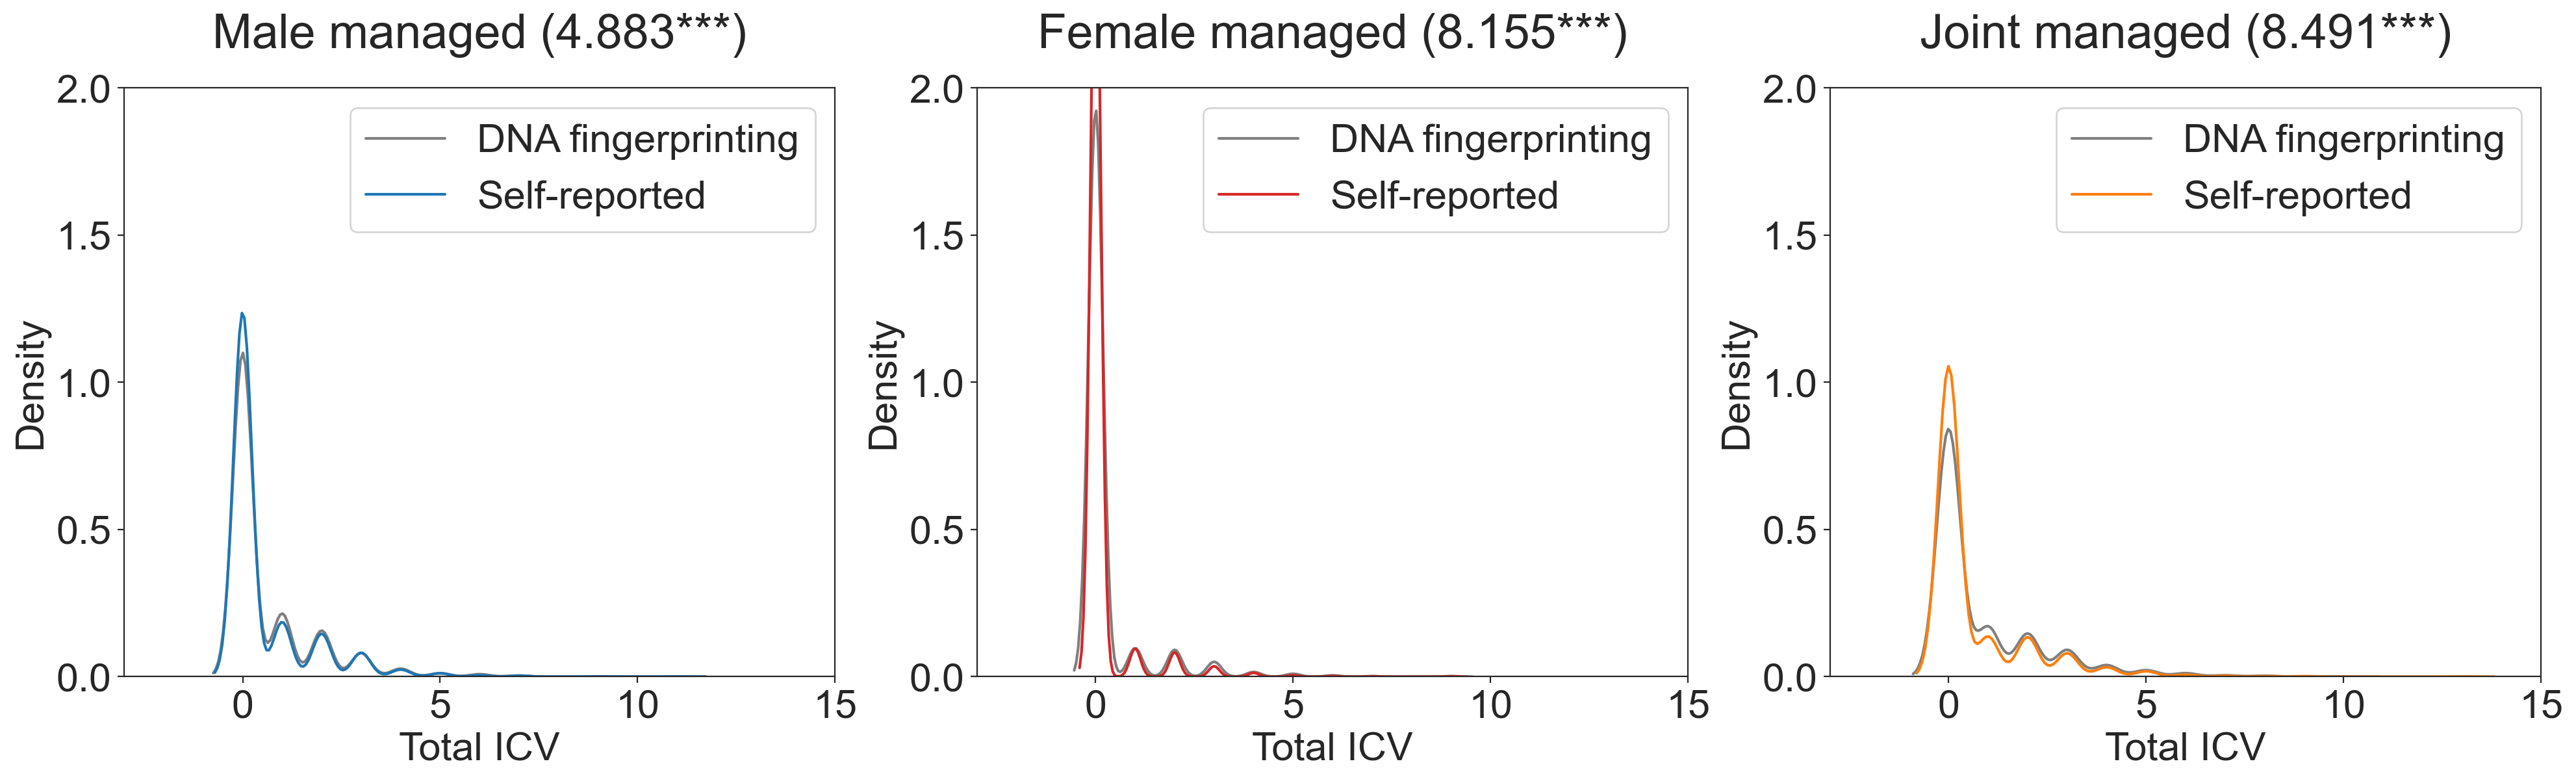

In [23]:
fig1, ax1 = plt.subplots(1, 3, figsize=(24,6), dpi=200)
plt.rcParams.update({'font.size': 22})


for index, _ in enumerate(['Male', 'Female', 'Joint']):
    # fig1, ax1 = plt.subplots(1, 3, figsize=(21,5), dpi=200)

    var = f'Total ICV {_}'
    c = {'Male': 'C0', 'Female': 'C3', 'Joint': 'C1'}
    sns.kdeplot(df_CMS_HH_DNA[var + " - DNA"], ax = ax1[index],  color="C7", label ="DNA fingerprinting")
    sns.kdeplot(df_CMS_HH_DNA[var + " - Survey"], ax = ax1[index], color=c[_], label ="Self-reported")
    ttest = ttest_rel(df_CMS_HH_DNA[f'{var} - DNA'], df_CMS_HH_DNA[f'{var} - Survey'], nan_policy='omit')
    
    data = []
    print('DNA fingerprinting vs Self-reported', convert_pvalue(ttest[0], ttest[1]))
    # df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])
    # ax1.table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
    #           cellLoc='left', colWidths=[0.8, 0.3], bbox = (0.4, 0.05, 0.55, 0.15), loc='lower right', zorder=10)


    ax1[index].set_ylabel('Density')
    ax1[index].set_xlabel('Y/N ICV' if var == 'planted' else 'Total ICV')
    #ax1[index].set_xlim(-1, 6)
    ax1[index].set_title(f'{_} managed ({convert_pvalue(ttest[0], ttest[1])})', y=1.05)
    ax1[index].legend(loc=1)
    
    ax1[index].set_ylim(0, 2)
    ax1[index].set_xlim(-3, 15)
    ax1[index].set_yticks([0, 0.5, 1, 1.5, 2])


fig1.savefig(f"../Manuscript/Figures/Figure_5.pdf", dpi=600, bbox_inches='tight' )

['DNA fingerprinting vs Self-reported', '4.933***']
['DNA fingerprinting vs Self-reported', '-0.258']
['DNA fingerprinting vs Self-reported', '2.467**']
['DNA fingerprinting vs Self-reported', '8.105***']
['DNA fingerprinting vs Self-reported', '7.139***']
['DNA fingerprinting vs Self-reported', '4.706***']


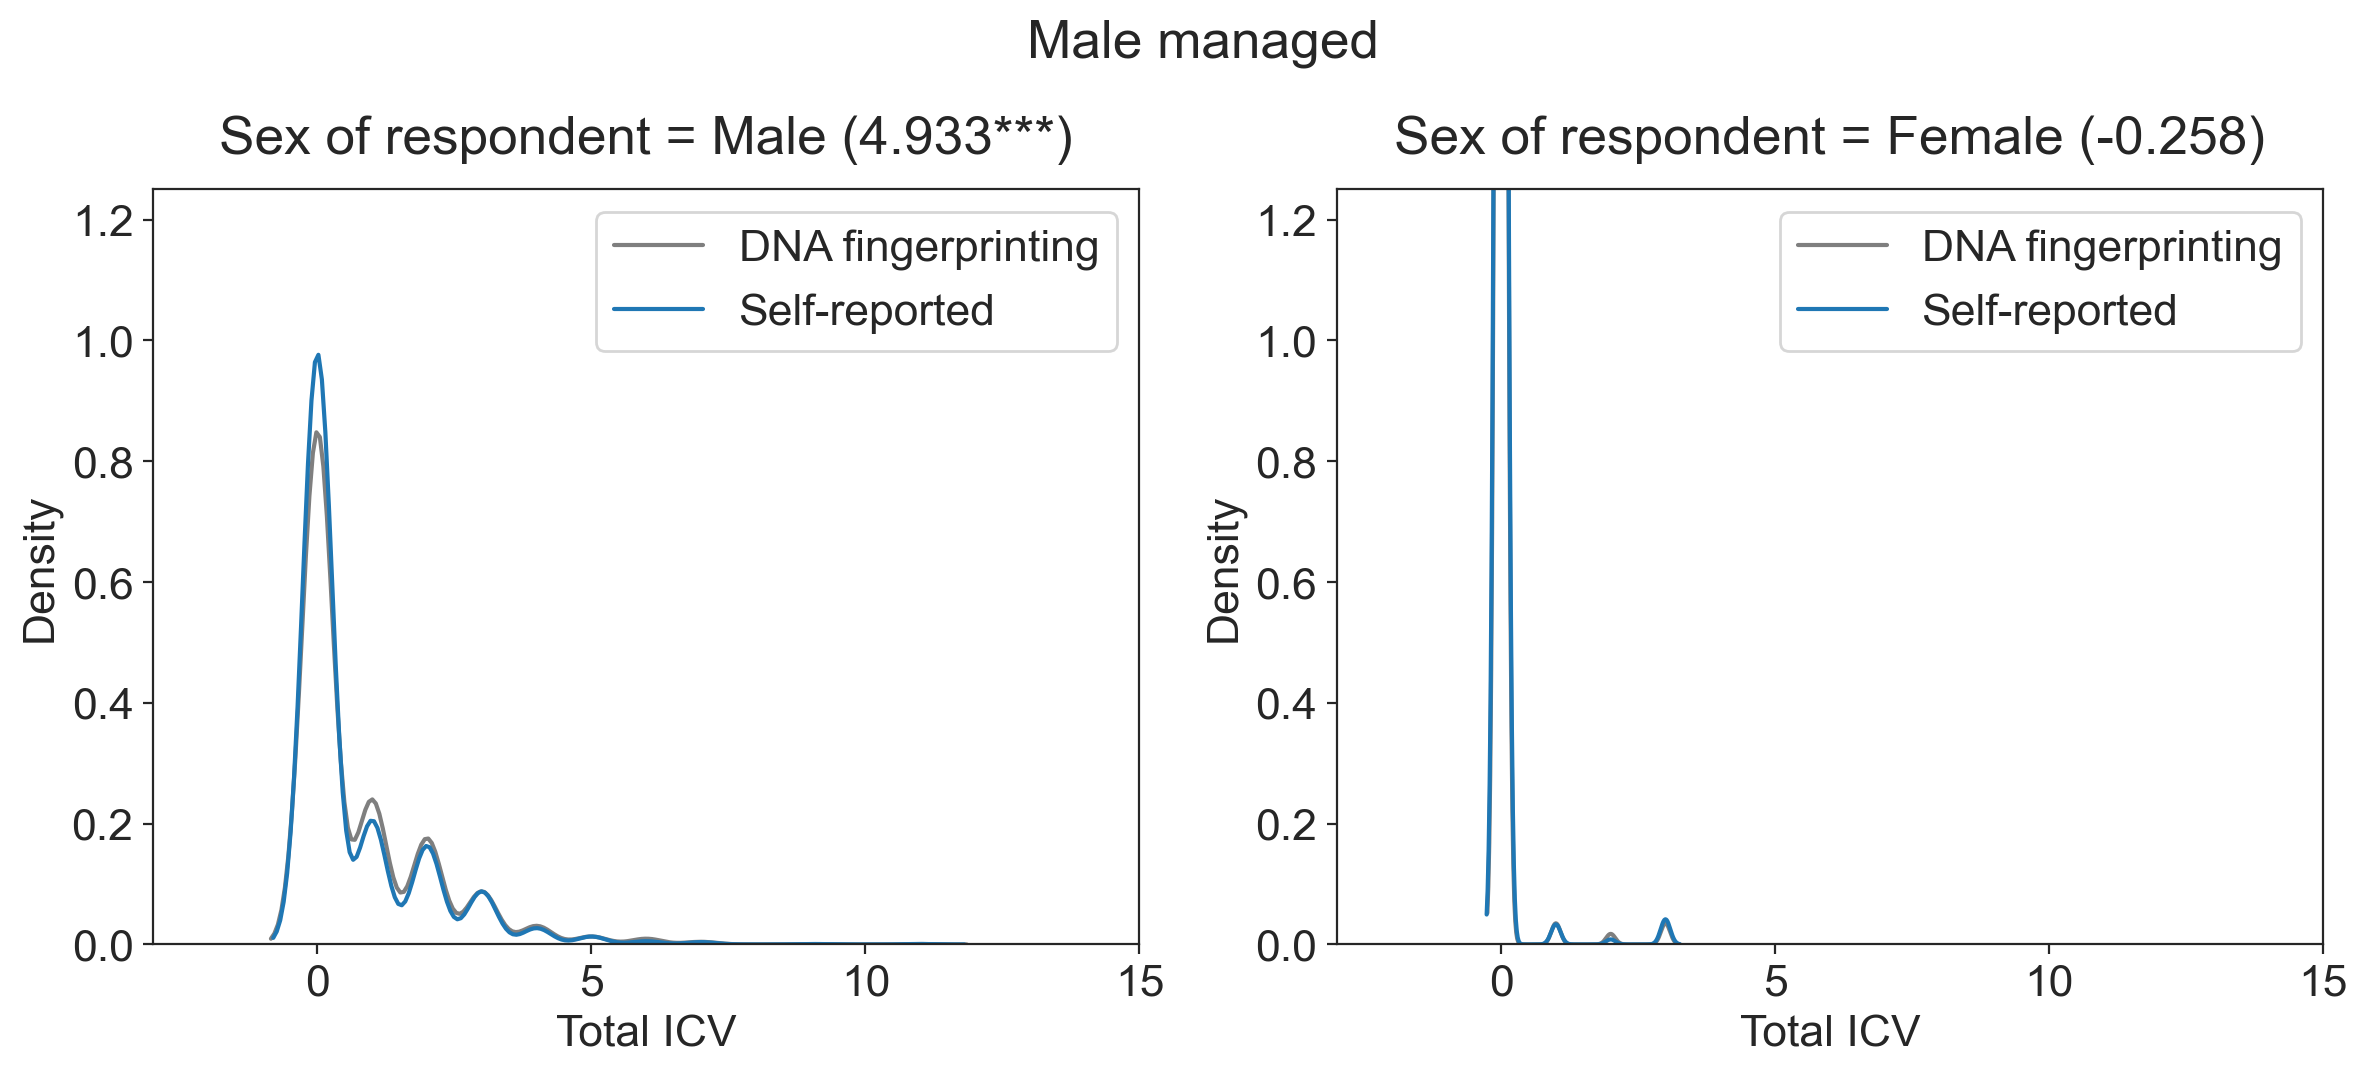

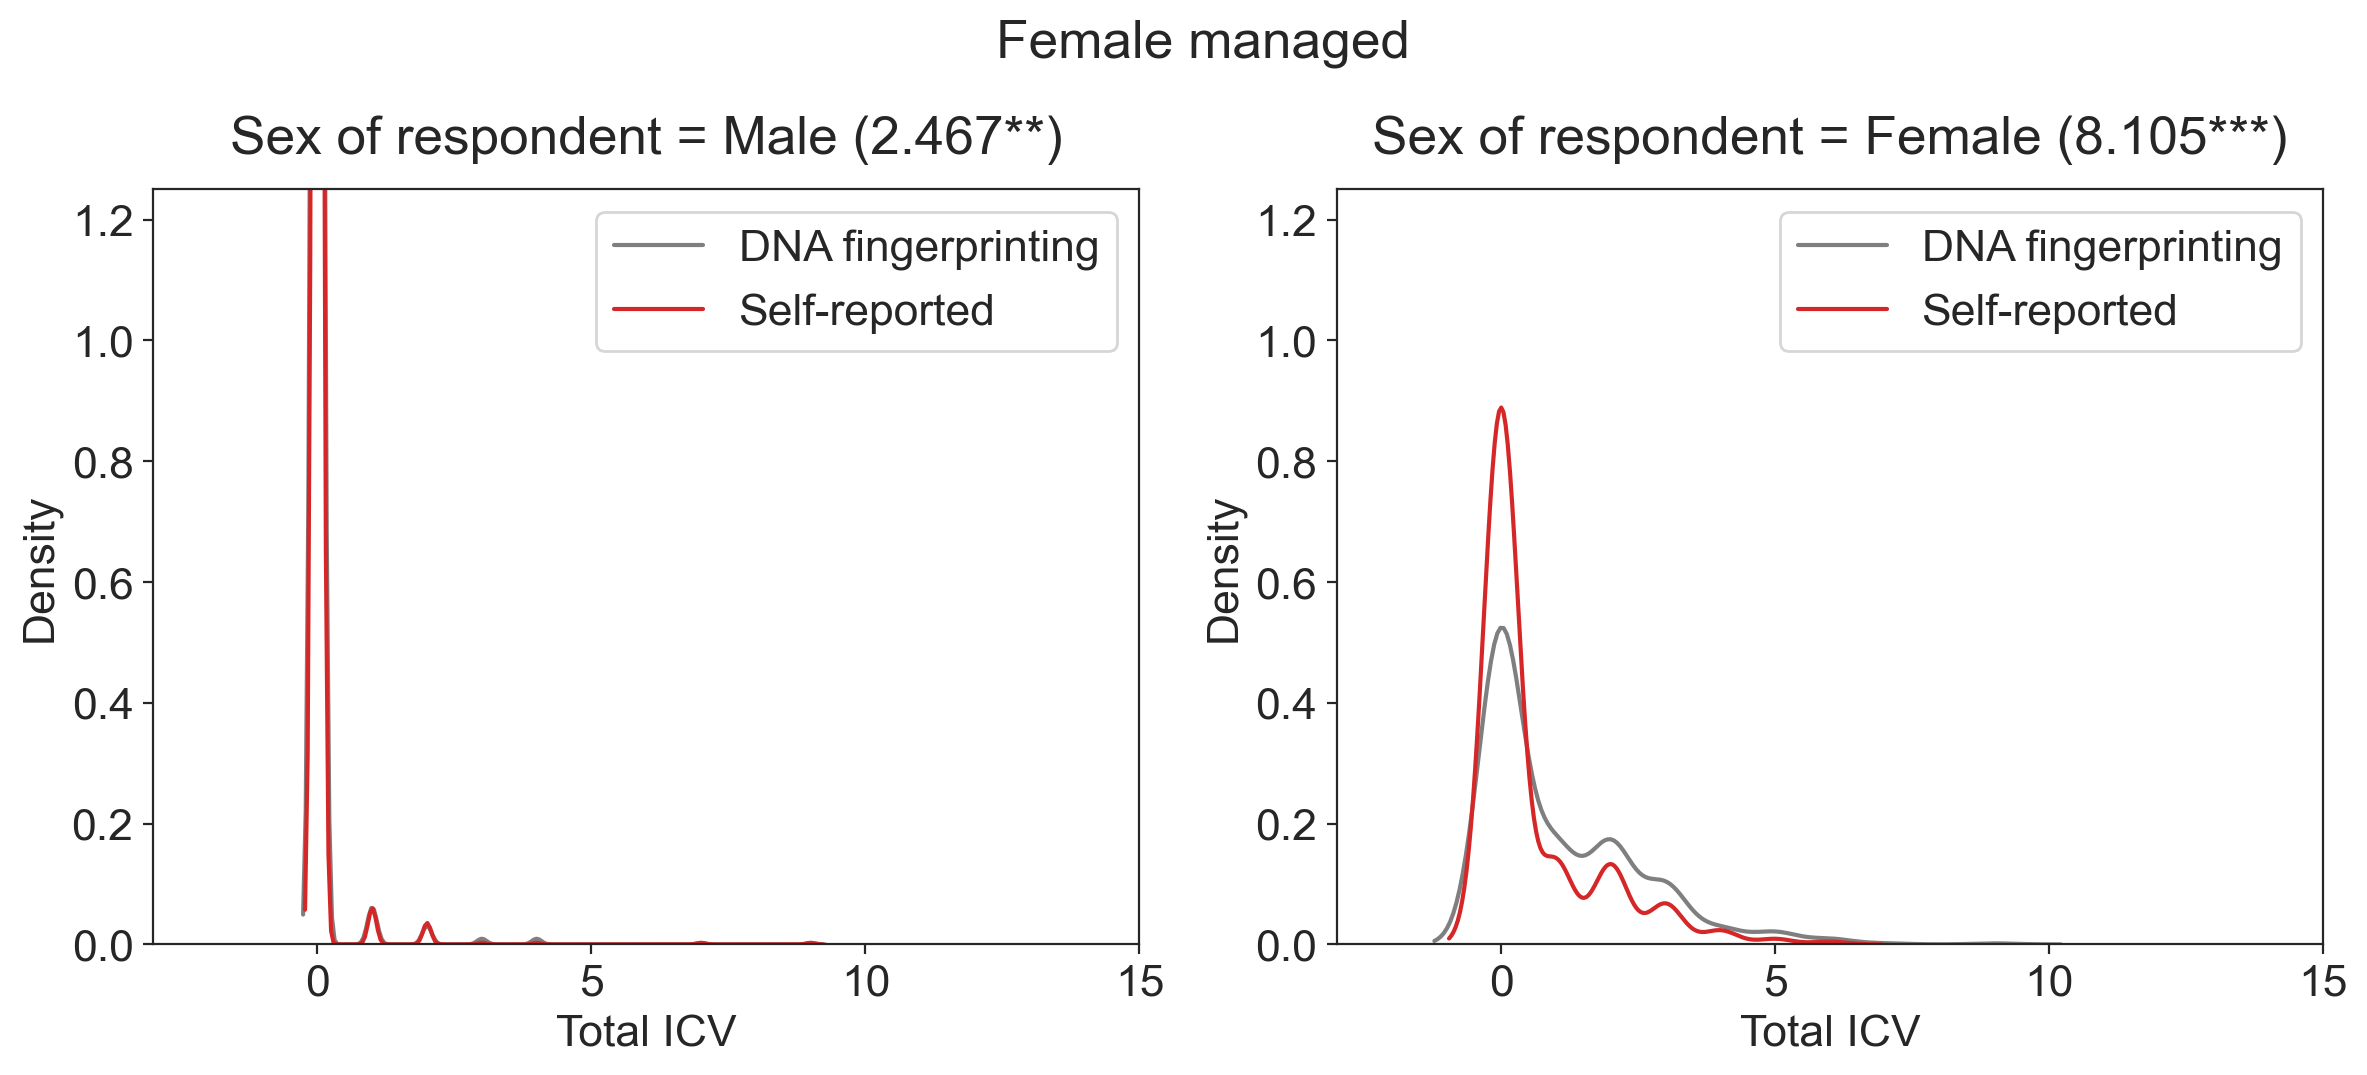

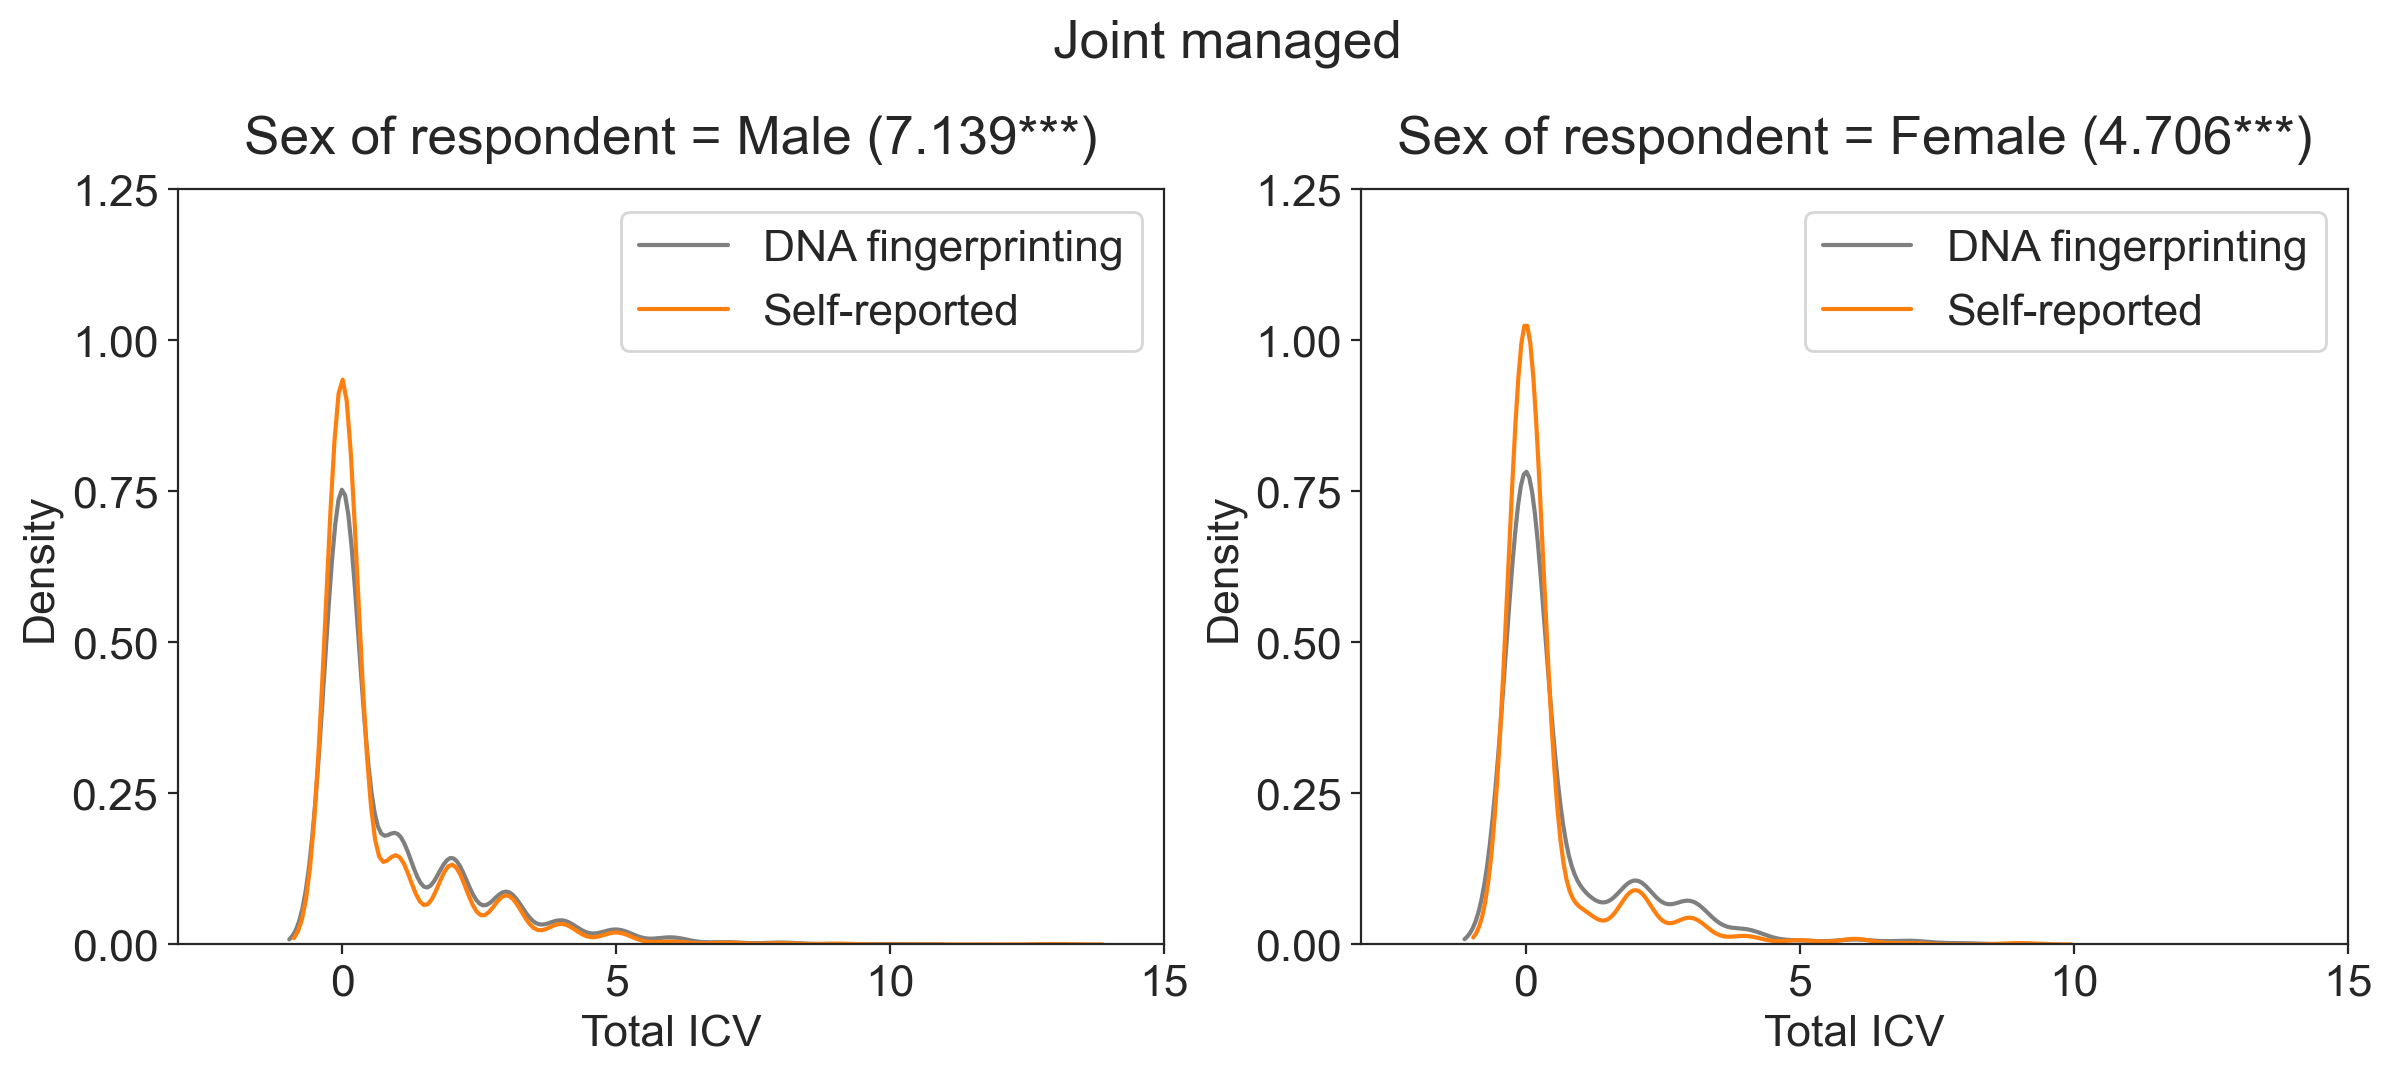

In [44]:
var = 'Total ICV Joint'
plt.rcParams.update({'font.size': 16})

for _, color in zip(['Male', 'Female', 'Joint'], ['C0', 'C3', 'C1']):
    var = 'Total ICV ' + _

    fig1, ax1 = plt.subplots(1, 2, figsize=(14,5), dpi=200)
    df_CMS_HH_DNA_male = df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Male']
    df_CMS_HH_DNA_female = df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Female']
    
    sns.kdeplot(df_CMS_HH_DNA_male[var + " - DNA"], ax = ax1[0],  color="C7", label ="DNA fingerprinting")
    sns.kdeplot(df_CMS_HH_DNA_male[var + " - Survey"], ax = ax1[0], color=color, label ="Self-reported")
    
    
    sns.kdeplot(df_CMS_HH_DNA_female[var + " - DNA"], ax = ax1[1],  color="C7", label ="DNA fingerprinting")
    sns.kdeplot(df_CMS_HH_DNA_female[var + " - Survey"], ax = ax1[1], color=color, label ="Self-reported")

    ax1[0].set_xlabel('Total ICV')
    ax1[1].set_xlabel('Total ICV')
    # fig1.suptitle(f'{_} managed')
    ttest_HM = ttest_rel(df_CMS_HH_DNA_male[f'{var} - DNA'], df_CMS_HH_DNA_male[f'{var} - Survey'], nan_policy='omit')
    ttest_HF = ttest_rel(df_CMS_HH_DNA_female[f'{var} - DNA'], df_CMS_HH_DNA_female[f'{var} - Survey'], nan_policy='omit')

        
    # data = []
    # data.append(['DNA fingerprinting vs Self-reported', convert_pvalue(ttest_HM[0], ttest_HM[1])])
    # df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])
    # ax1[0].table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
    #           cellLoc='left', colWidths=[0.8, 0.3], bbox = (0.35, 0.05, 0.6, 0.15), loc='lower right', zorder=10)

    # data = []
    # data.append(['DNA fingerprinting vs Self-reported', convert_pvalue(ttest_HF[0], ttest_HF[1])])
    # df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])
    # ax1[1].table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
    #           cellLoc='left', colWidths=[0.8, 0.3], bbox = (0.35, 0.05, 0.6, 0.15), loc='lower right', zorder=10)
    print(['DNA fingerprinting vs Self-reported', convert_pvalue(ttest_HM[0], ttest_HM[1])])
    print(['DNA fingerprinting vs Self-reported', convert_pvalue(ttest_HF[0], ttest_HF[1])])
    
    ax1[0].set_ylabel('Density')
    ax1[0].set_xlabel('Y/N ICV' if var == 'planted' else 'Total ICV')

    ax1[1].set_ylabel('Density')
    ax1[1].set_xlabel('Y/N ICV' if var == 'planted' else 'Total ICV')


    ax1[0].set_title(f'Sex of respondent = Male ({convert_pvalue(ttest_HM[0], ttest_HM[1])})',  y=1.025)
    ax1[1].set_title(f'Sex of respondent = Female ({convert_pvalue(ttest_HF[0], ttest_HF[1])})', y=1.025)
    ax1[0].legend(loc=1)
    ax1[1].legend(loc=1)

    # ax1[0].set_ylim(0, 2)
    ax1[0].set_xlim(-3, 15)
    # ax1[0].set_yticks([0, 0.5, 1, 1.5, 2])

    # ax1[1].set_ylim(0, 2)
    ax1[1].set_xlim(-3, 15)
    # ax1[1].set_yticks([0, 0.5, 1, 1.5, 2])
    if _ != 'Joint':
        ax1[0].set_ylim(0, 1.25)
        ax1[1].set_ylim(0, 1.25)
    else: 
        ax1[0].set_yticks([0, 0.25, 0.5, 0.75, 1, 1.25])
        ax1[1].set_yticks([0, 0.25, 0.5, 0.75, 1, 1.25])
        
    fig1.suptitle(f'{_} managed', y=1.05)
    fig1.savefig(f"../Manuscript/Figures/Figure_6_{_}_managed.pdf", dpi=600, bbox_inches='tight' )